<a href="https://colab.research.google.com/github/NataliiaHromyk/HomeWork_Python_DS/blob/main/Hromyk_%22HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("drive/MyDrive/ML_files/marketing_campaign.csv", sep='\t')

In [4]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.00,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.00,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.00,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.00,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.00,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.00,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.00,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.00,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.00,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [5]:
df.info(verbose = True,  show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df['Z_Revenue'].value_counts()

,count
Z_Revenue,
11,2240


In [7]:
df['Z_CostContact'].value_counts()

,count
Z_CostContact,
3,2240


Даний датафрейм має 2240 рядків та 29 колонок, з них три поля - текстові, два з них можна розкласти за допомогою ванхот кодингу, третє (дата реєстрації клієнта у компанії) - можна знайти скільки років/днів користувач перебуває у компанії. Решта колонок є числовими (25 типу int64, ще 1 типу float)

Пусті значення присутні тільки в полі Income, їхня к-сть становить всього 24 одиниці з 2 240 - це 1%. Теоретично, ми навіть можемо знехтувати цими даними

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [8]:
df[df.isnull().any(axis=1)]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,3,11,0


In [9]:
df['Income'].describe()

,Income
count,2216.00
mean,52247.25
std,25173.08
min,1730.00
25%,35303.00
50%,51381.50
75%,68522.00
max,666666.00


Пропоную пусті значення заповнити середнім чи медіаною

In [10]:
df['Income'].mean()

np.float64(52247.25135379061)

In [11]:
df['Income'].fillna(value = df['Income'].mean(), inplace = True)

/tmp/ipython-input-3477634461.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(value = df['Income'].mean(), inplace = True)


In [12]:
df.isnull().values.any()

np.False_

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [13]:
df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [14]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


Категоріальним колонкам у даному випадку пропоную зробити OneHotEncoding

In [15]:
from sklearn.preprocessing import OneHotEncoder

In [16]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [17]:
one_hot_cols = ['Education','Marital_Status']

In [18]:
encoder.fit(df[one_hot_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [19]:
encoded_cols = list(encoder.get_feature_names_out(one_hot_cols))
print(encoded_cols)

['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Absurd', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO']


In [20]:
df[encoded_cols] = encoder.transform(df[one_hot_cols])

Взагалі до ванходекнодингу був варіант заміни значень на числові, проте зрозуміла, що показники типу коли людина одружена, самотня чи розведена будуть на різних відстаннях один від одного і думаю, що це буде не зовсім коректно. Якщо не права, то буду вдячна за рекомендацію та пояснення :)

Стосовно дати, як і пропонувалось вище - рекомендую просто мінуснути дату від сьогоднішнього числа

In [21]:
from datetime import datetime, date, timedelta

In [22]:
df['Dt_customer_in_day'] = (datetime.today() - pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')).dt.days
df['Dt_customer_in_day']

,Dt_customer_in_day
0,4801
1,4251
2,4450
3,4277
4,4299
...,...
2235,4519
2236,4157
2237,4293
2238,4294


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [23]:
df['Z_Revenue'].value_counts(), df['Z_CostContact'].value_counts()

(Z_Revenue
 11    2240
 Name: count, dtype: int64,
 Z_CostContact
 3    2240
 Name: count, dtype: int64)

поля Z_Revenue та Z_CostContact не будемо використовувати, оскільки вони містять по одному значенню

In [24]:
cols_for_clasterisation = ['Year_Birth','Income','Kidhome','Teenhome','Recency','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp1','AcceptedCmp2','Complain','Dt_customer_in_day'] + encoded_cols
print(cols_for_clasterisation)

['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Dt_customer_in_day', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Absurd', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO']


In [25]:
X = df[cols_for_clasterisation]

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.datasets import load_wine, load_iris

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[0 1 0 ... 0 0 0]


In [28]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


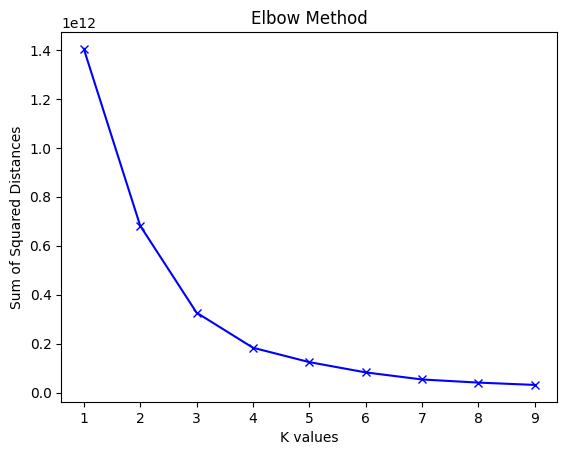

In [29]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

Взагалі метод ліктя демонструє, що можна розбити на 4 кластери для кращих результатів

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [30]:
X.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Dt_customer_in_day,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
count,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,27.06,44.02,2.33,4.08,2.66,5.79,5.32,0.07,0.07,0.07,0.06,0.01,0.01,4491.58,0.09,0.02,0.50,0.17,0.22,0.00,0.00,0.10,0.39,0.21,0.26,0.03,0.00
std,11.98,25037.80,0.54,0.54,28.96,336.60,39.77,225.72,54.63,41.28,52.17,1.93,2.78,2.92,3.25,2.43,0.26,0.26,0.26,0.25,0.11,0.10,202.12,0.29,0.15,0.50,0.37,0.41,0.03,0.04,0.30,0.49,0.41,0.44,0.18,0.03
min,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4138.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1959.00,35538.75,0.00,0.00,24.00,23.75,1.00,16.00,3.00,1.00,9.00,1.00,2.00,0.00,3.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,4318.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1970.00,51741.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,8.00,24.00,2.00,4.00,2.00,5.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,4493.50,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1977.00,68289.75,1.00,1.00,74.00,504.25,33.00,232.00,50.00,33.00,56.00,3.00,6.00,4.00,8.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,4667.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
max,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,263.00,362.00,15.00,27.00,28.00,13.00,20.00,1.00,1.00,1.00,1.00,1.00,1.00,4837.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [31]:
X['3_clust_KMeans']=labels

/tmp/ipython-input-3982054156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['3_clust_KMeans']=labels


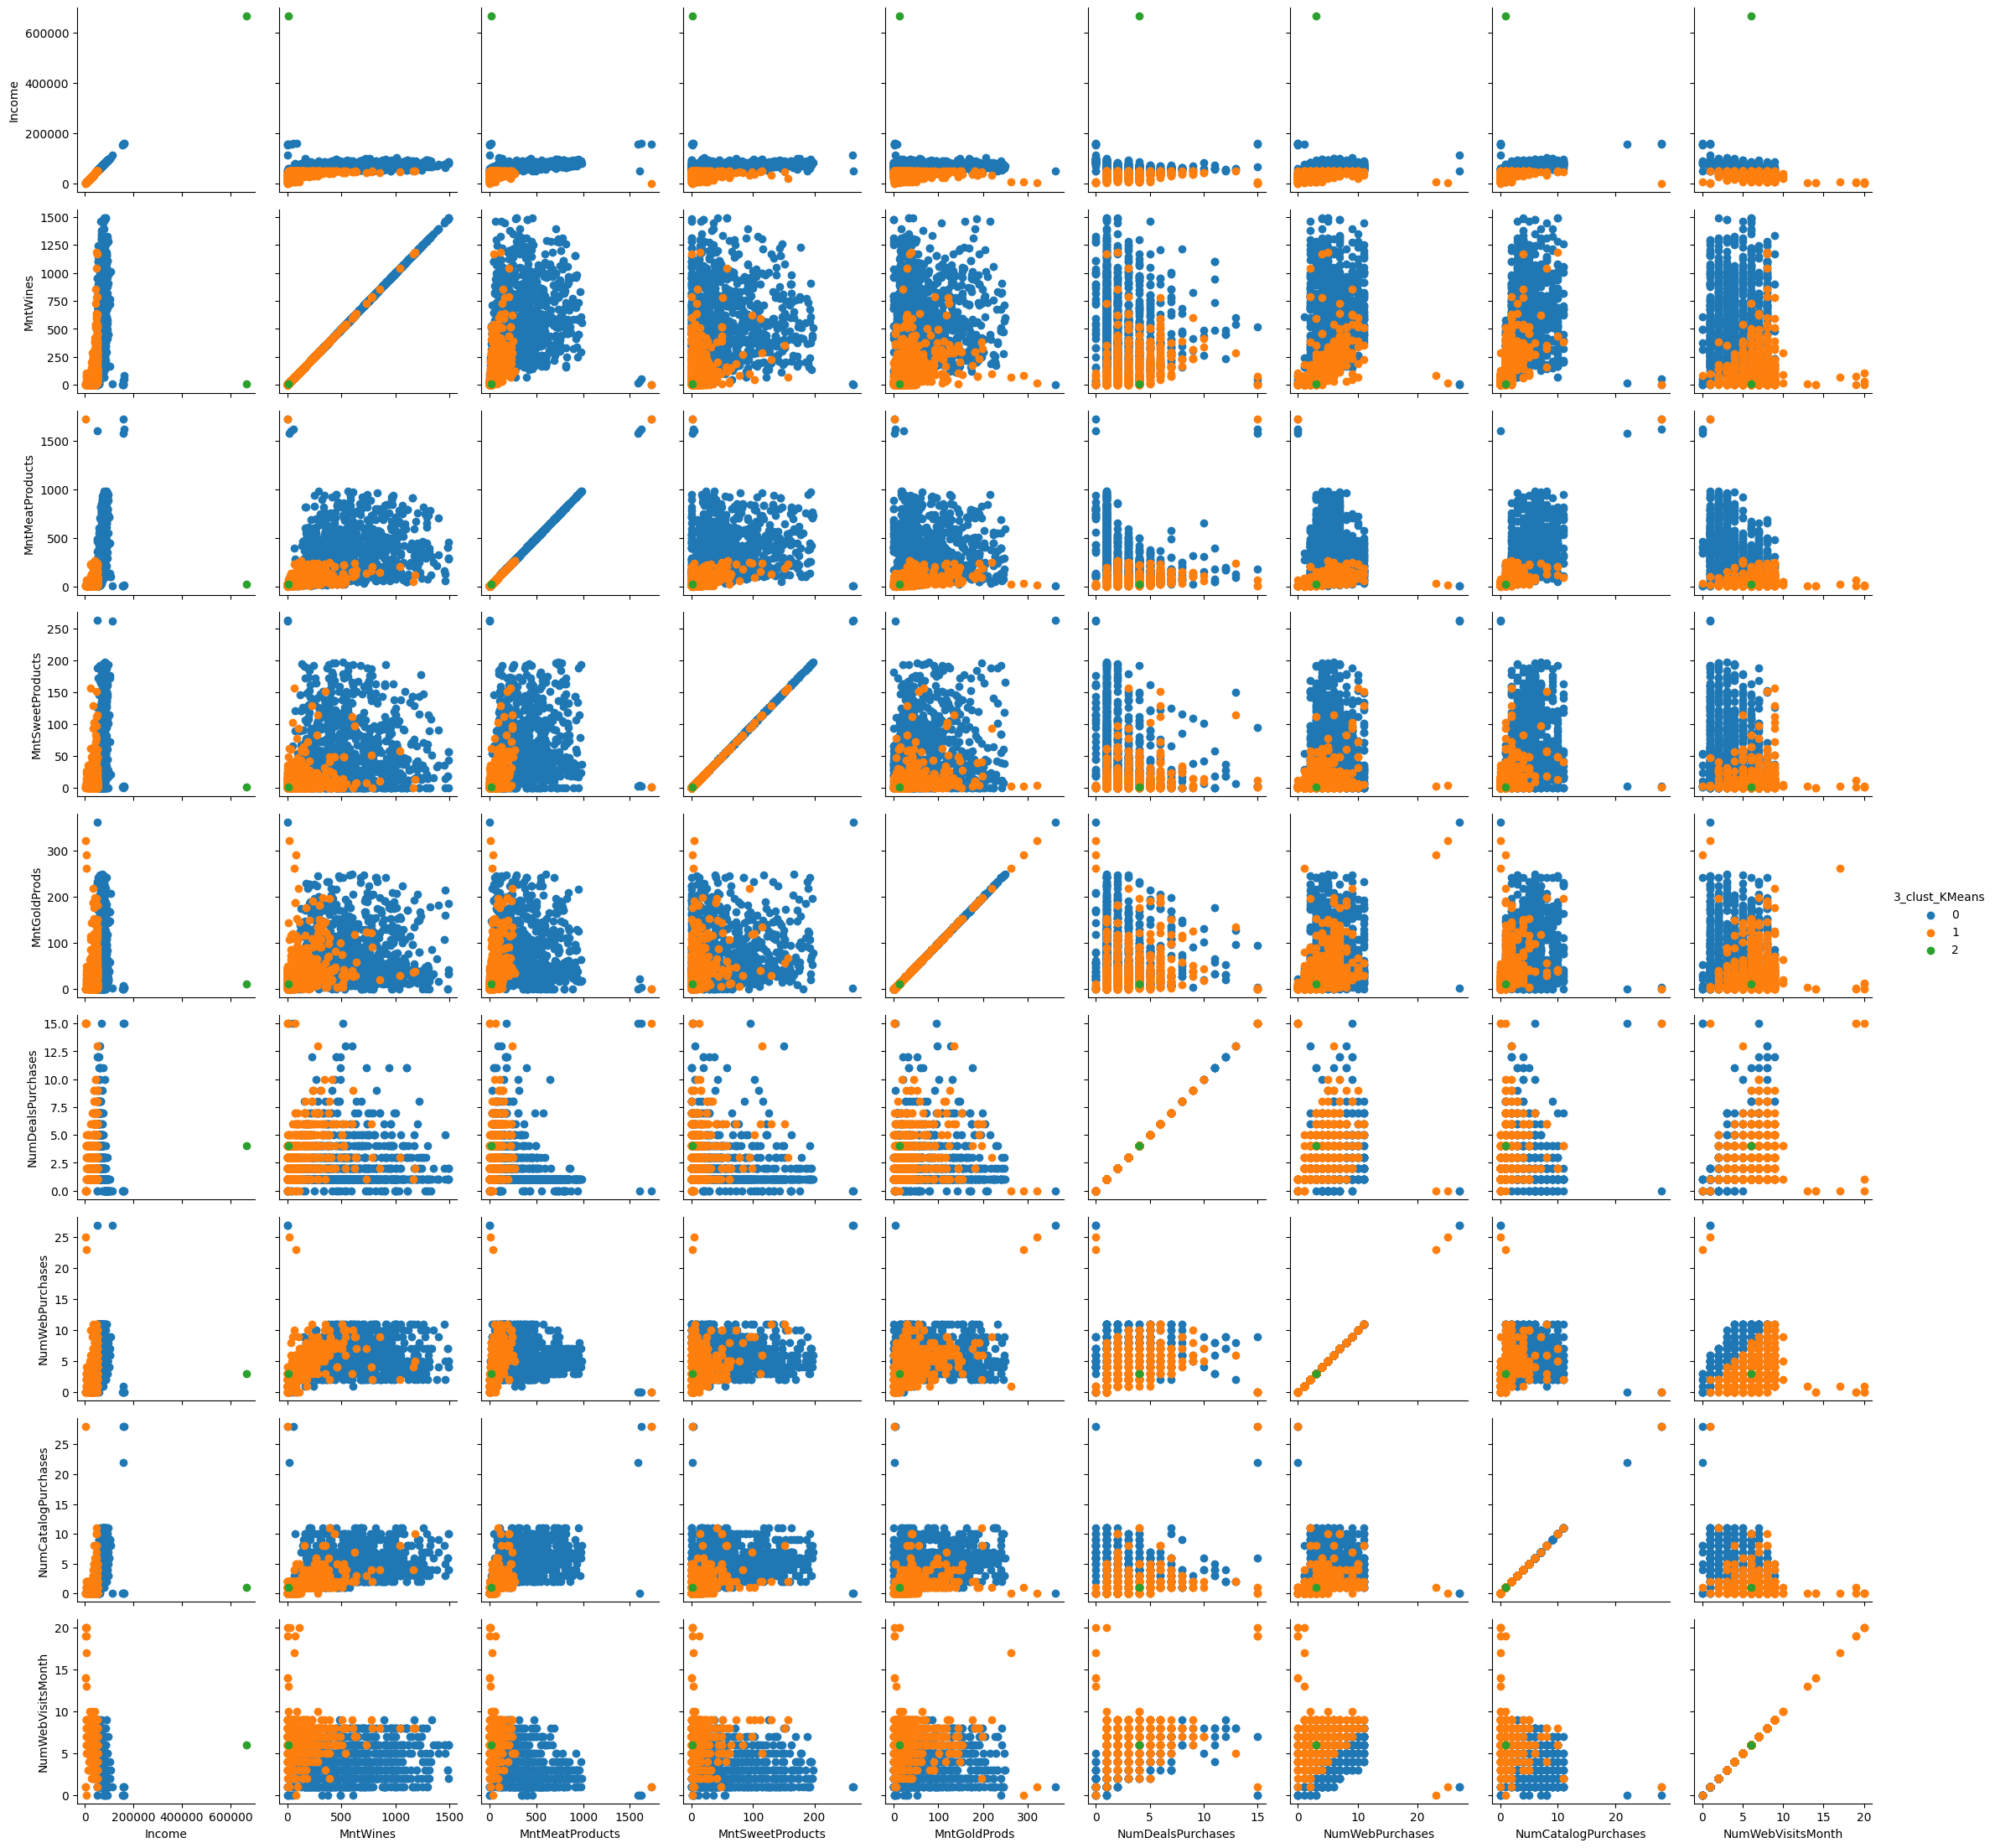

In [32]:
g = sns.PairGrid(
    X,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='3_clust_KMeans')
g.map(plt.scatter)
g.add_legend();

По даним чітко видно викид по сумі доходу, котрий і являється третім кластером (вказаний в таблиці як 2), в ідеалі потрібно його переглянути дані викиди і в більшій мірі виключити з даних
По іншим двум кластерам чітко помітно різницю від доходу - якщо користувач має вищий дохід, то відноситься до нульового кластеру. Також помітна залежність по к-сті куплених продуктів - більше куплених продуктів (чи то вина, чи то м'яса) - відноситься до нульового кластеру

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X[cols_for_clasterisation])
X_scaler = pd.DataFrame(scaler.transform(X[cols_for_clasterisation]), columns=cols_for_clasterisation)

In [34]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_scaler)

labels = kmeans.predict(X_scaler)
print(labels)

[1 1 1 ... 1 1 0]


In [35]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_scaler, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.14


In [36]:
X_scaler['3_clust_KMeans_Scaler']=labels

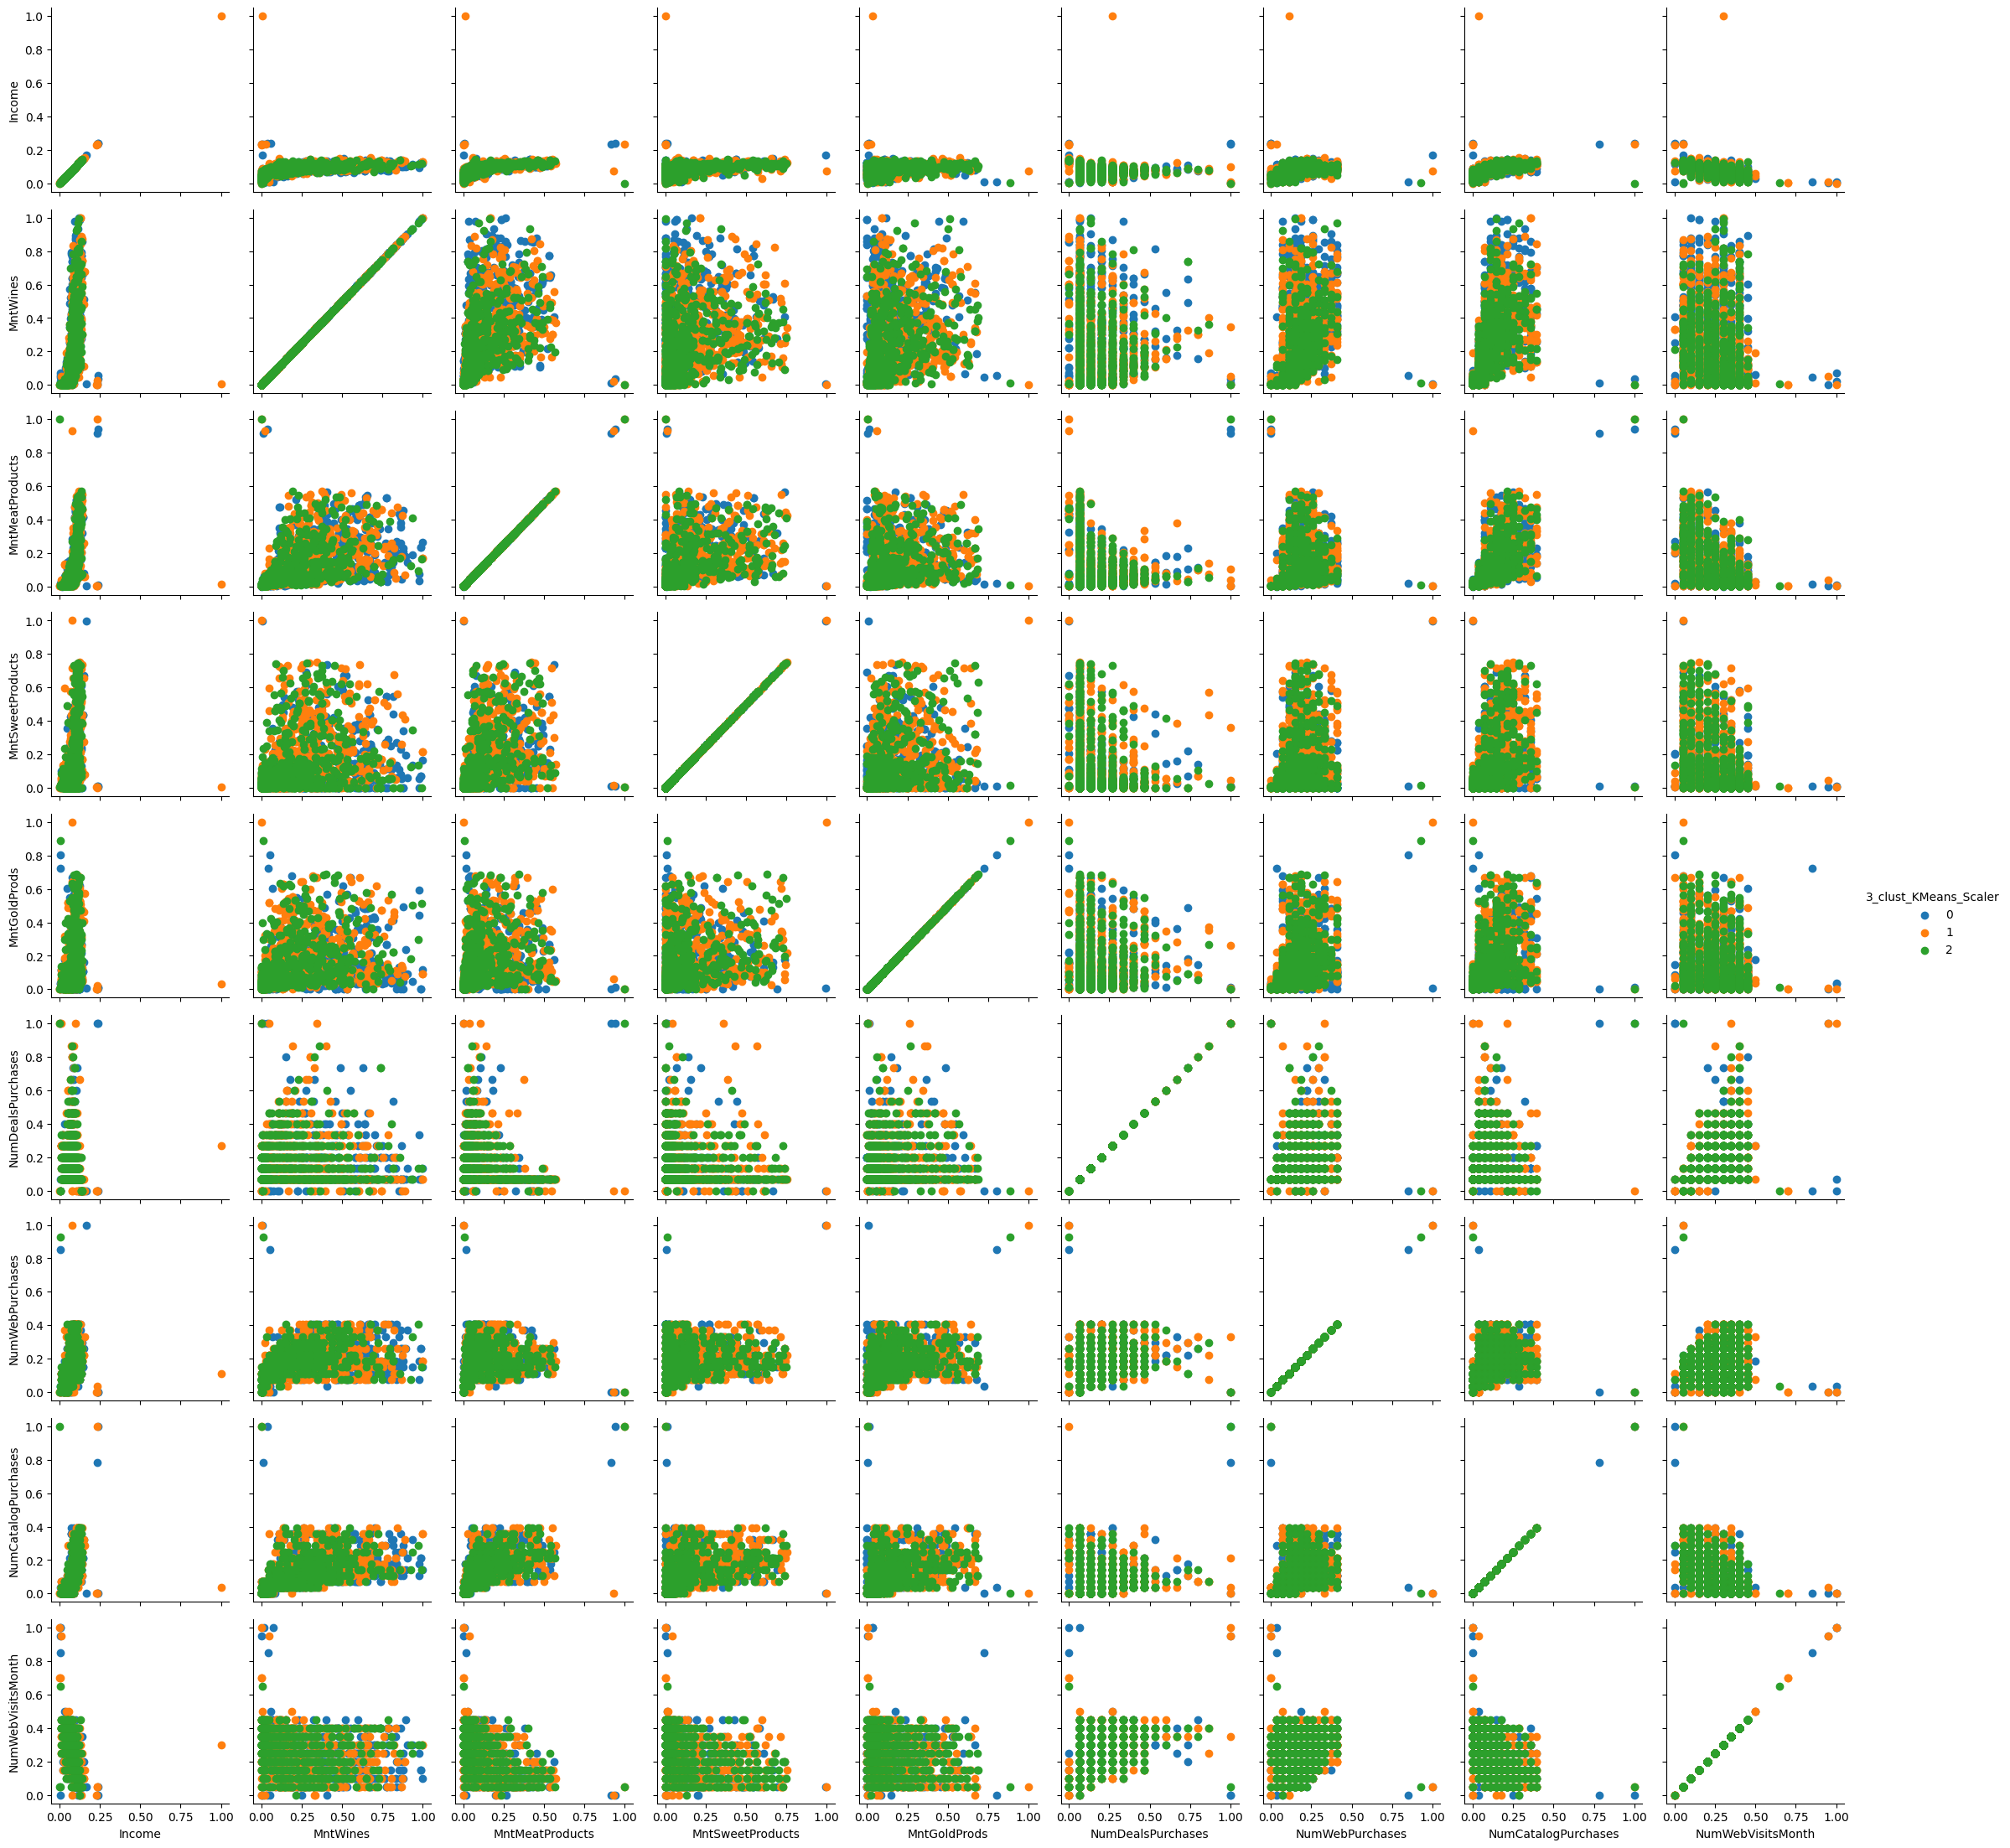

In [37]:
g = sns.PairGrid(
    X_scaler,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='3_clust_KMeans_Scaler')
g.map(plt.scatter)
g.add_legend();

Метрика силуету на маштабованих даних погіршилась - це означає, що виділені кластери добре збігаються один з одним і складно виділити той особливий.

За рахунок того, що MinMaxScaler стискає всі значення у [0, 1],
включаючи викид, викид стає уже не таким особливим та відчутним для кластеризації.
Але водночас він викривляє розподіл решти даних, бо через нього мінімум і максимум сильно зсуваються.
Як результат, модель намагається розділити дуже зім’яті дані(всі значення звузились). Відповідно, кластери стають без особливого сенсу, бо центри кластерів сильно співпадатимуть один з одним

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [38]:
import warnings

def dist_box(dataset, column):
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")

      plt.figure(figsize=(16,6))

      plt.subplot(1,2,1)
      sns.distplot(dataset[column], color = 'purple')
      pltname = 'Графік розподілу для ' + column
      plt.ticklabel_format(style='plain', axis='x')
      plt.title(pltname)

      plt.subplot(1,2,2)
      red_diamond = dict(markerfacecolor='r', marker='D')
      sns.boxplot(y = column, data = dataset, flierprops = red_diamond)
      pltname = 'Боксплот для ' + column
      plt.title(pltname)

      plt.show()

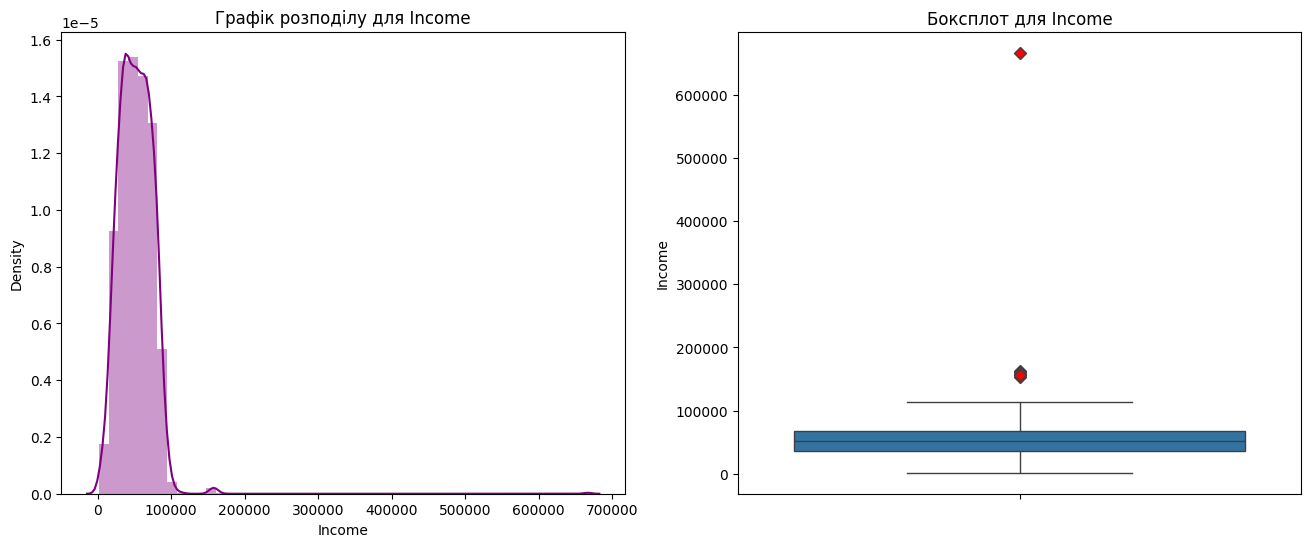

In [39]:
dist_box(X,'Income')

In [40]:
Q1 = X['Income'].quantile(0.25)
Q3 = X['Income'].quantile(0.75)
IQR = Q3 - Q1

Min_value0 = (Q1 - 1.5 * IQR)
Max_value0 = (Q3 + 1.5 * IQR)
print(IQR)
print("Мінімальне значення, до якого існують викиди: {}".format(Min_value0))
print("Максимальне значення, після якого існують викиди: {}".format(Max_value0))

32751.0
Мінімальне значення, до якого існують викиди: -13587.75
Максимальне значення, після якого існують викиди: 117416.25


In [41]:
#Outliers
X[X['Income'] >= Max_value0]

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Dt_customer_in_day,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,3_clust_KMeans
164,1973,157243.00,0,1,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,4258,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0
617,1976,162397.00,1,1,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,4529,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0
655,1975,153924.00,0,0,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,4280,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0
687,1982,160803.00,0,0,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,0,0,0,0,4832,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0
1300,1971,157733.00,1,0,37,39,1,9,2,0,8,0,1,0,1,1,0,0,0,0,0,0,4528,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0
1653,1977,157146.00,0,0,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,4564,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0
2132,1949,156924.00,0,0,85,2,1,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,4442,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0
2233,1977,666666.00,1,0,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,4530,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,2


In [42]:
#записуємо в датафрейм дані без викидів
X = X[X['Income'] < Max_value0]

In [43]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X[cols_for_clasterisation])

labels = kmeans.predict(X[cols_for_clasterisation])
print(labels)


[2 2 1 ... 2 1 2]


In [44]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X[cols_for_clasterisation], labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')


Silhouette Coefficient for the data Dataset Clusters: 0.55


In [45]:
X['3_clust_KMeans']=labels

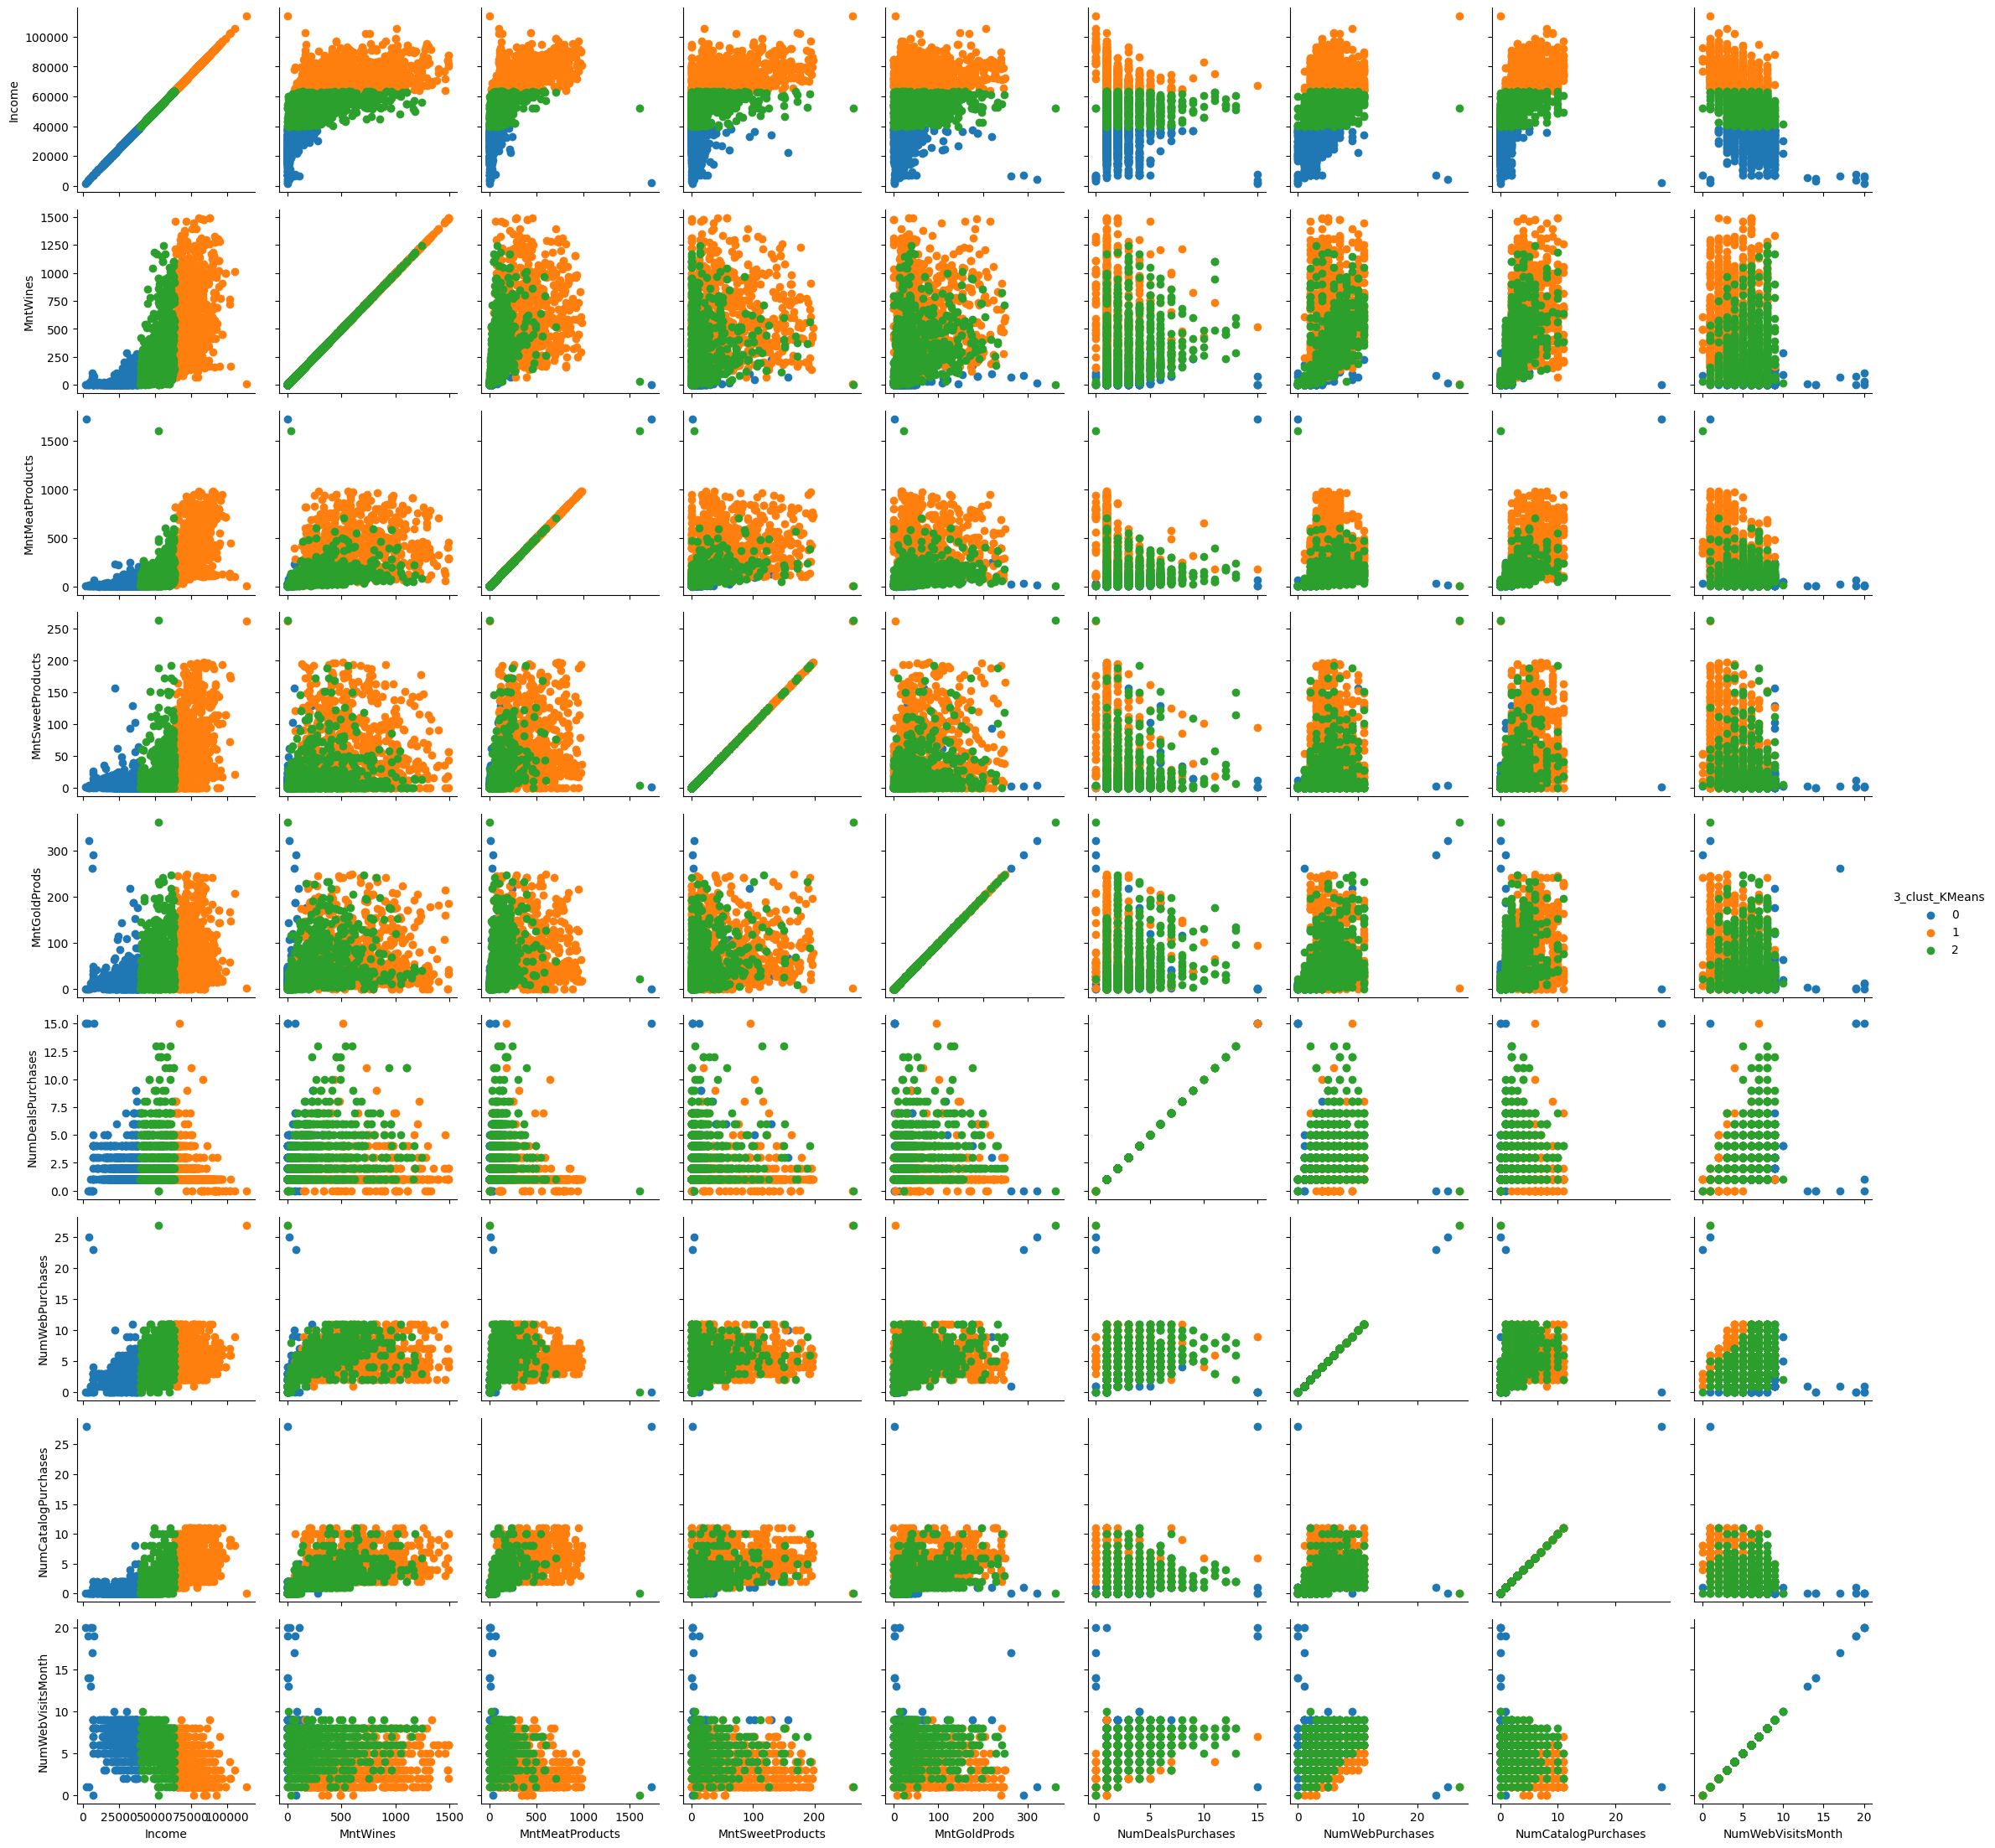

In [46]:
g = sns.PairGrid(
    X,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='3_clust_KMeans')
g.map(plt.scatter)
g.add_legend();

До речі, після видалення викидів  показник силуету погіршився, але по факту це відбулось за рахунок прибирання викидів і дані стали більш скупчені один біля одного. Чітко помітно, як кластери розподілились за рахунок доходу і це являється основним показником для кластеризації

Візуалізація побудована на звичайних даних, не масштабованих

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

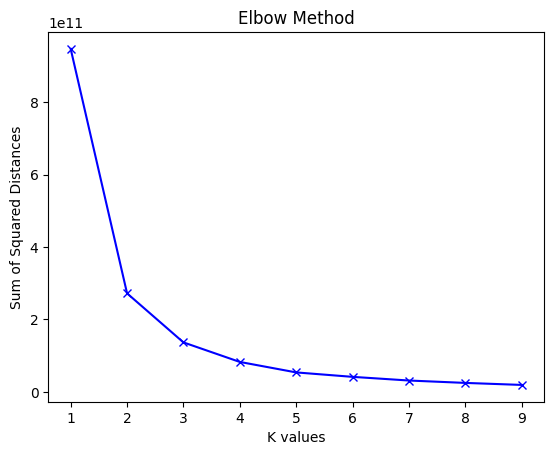

In [47]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

Взагалі, мені найбільше підходить варіант побудови даних на три кластери, але як варіант можемо спробувати на 4. Зроблю міні предикт, що показник силуету погіршиться, враховуючи що точки будуть більш скупчені поруч

In [48]:
kmeans = KMeans(n_clusters=4, n_init='auto')
kmeans.fit(X[cols_for_clasterisation])

labels = kmeans.predict(X[cols_for_clasterisation])
print(labels)


[1 0 3 ... 1 1 1]


In [49]:

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X[cols_for_clasterisation], labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.53


Як і очікувалось, показник силуету погіршився зі збільшеною к-стю кластерів

In [50]:
X['4_clust_KMeans']=labels

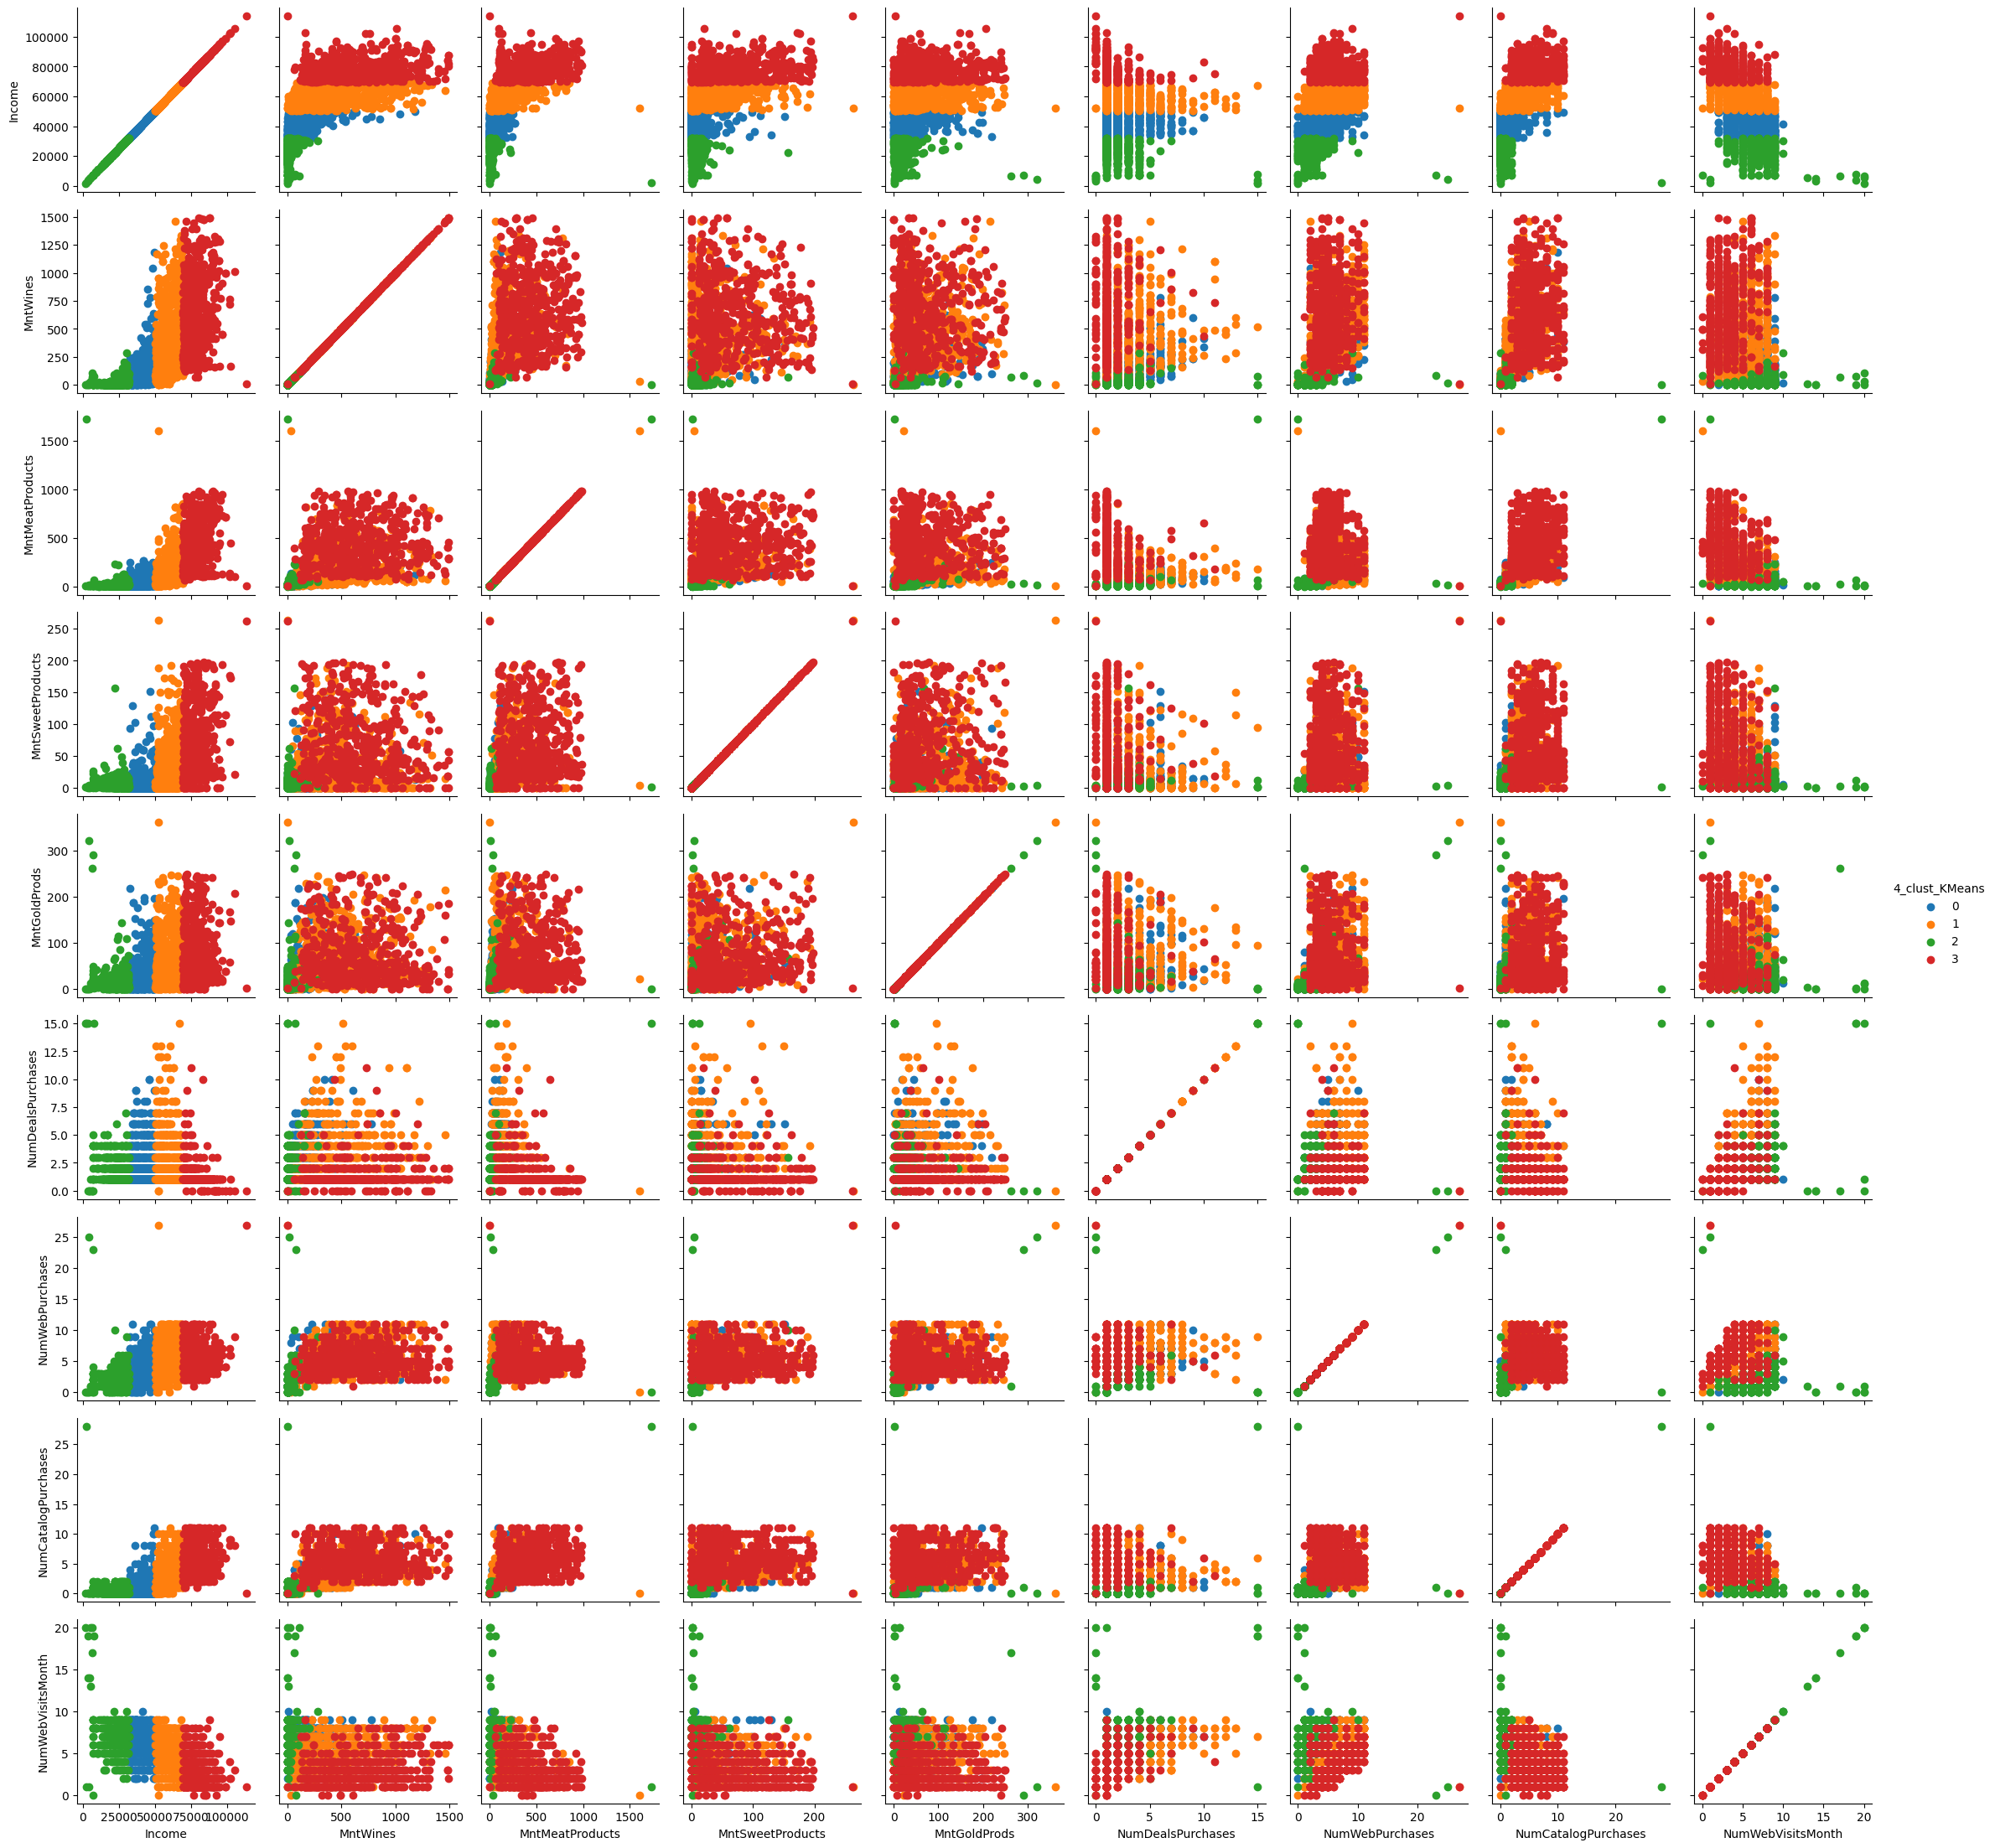

In [51]:

g = sns.PairGrid(
    X,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='4_clust_KMeans')
g.map(plt.scatter)
g.add_legend();

Загалом так, ми можемо використовувати і 3, і 4 кластери все в залежності від задачі - якщо потрібно більш ширше розділити дані, то на 4 кластери, а якщо це не відіграє ролі.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [52]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

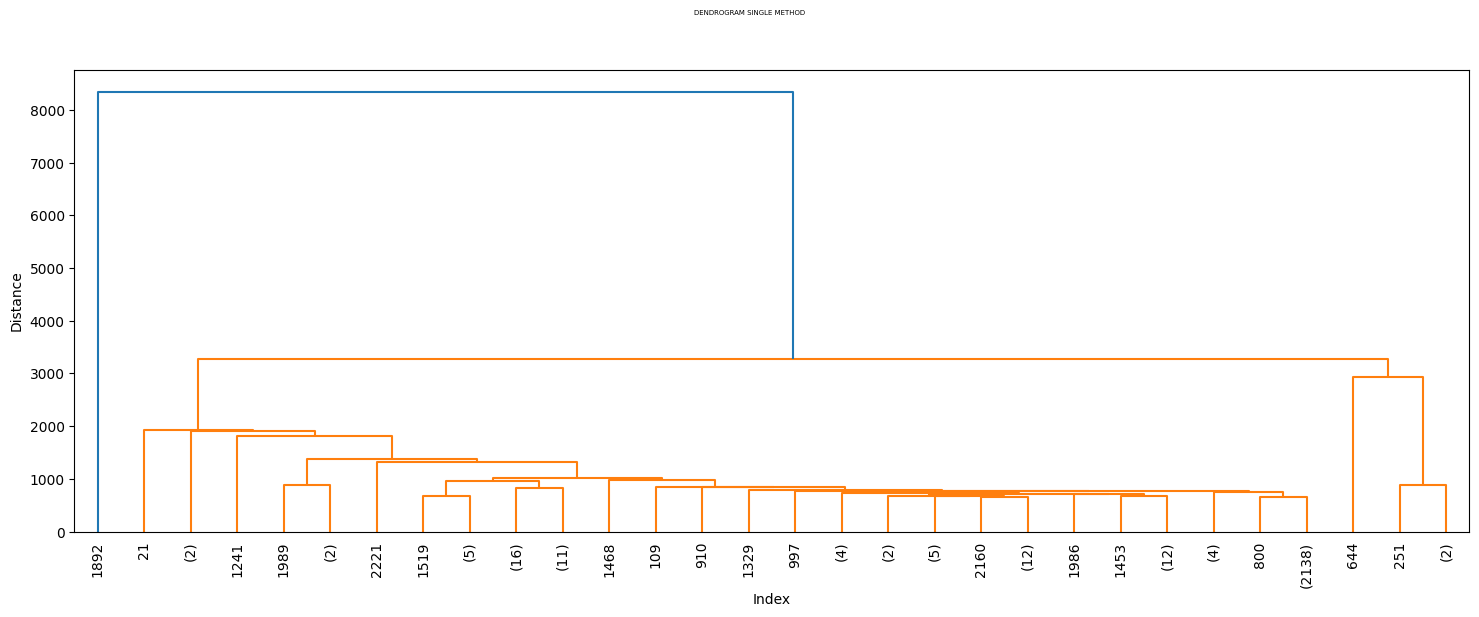

In [53]:
dist_sin = linkage(X[cols_for_clasterisation], method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=5)
plt.show()

Побудуємо кластеризацію на 2 і 3 кластери, а потім порівняємо результати.

In [54]:
X['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')
X['5_clust'] = fcluster(dist_sin, 5, criterion='maxclust')

<Axes: title={'center': 'K = 5'}, xlabel='Income', ylabel='MntMeatProducts'>

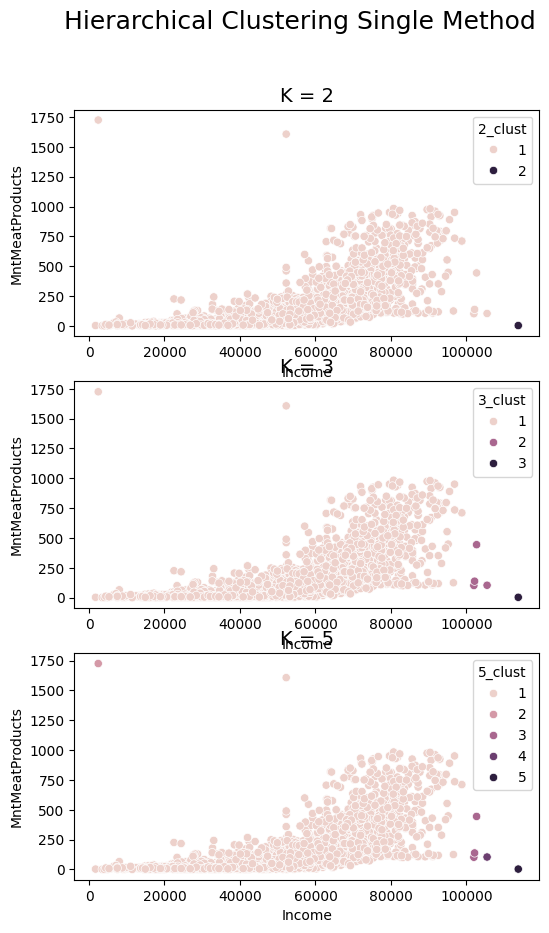

In [55]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="MntMeatProducts", data=X, hue="2_clust")

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="MntMeatProducts", data=X, hue="3_clust")

plt.subplot(3,1,3)
plt.title("K = 5",fontsize=14)
sns.scatterplot(x="Income",y="MntMeatProducts", data=X, hue="5_clust")

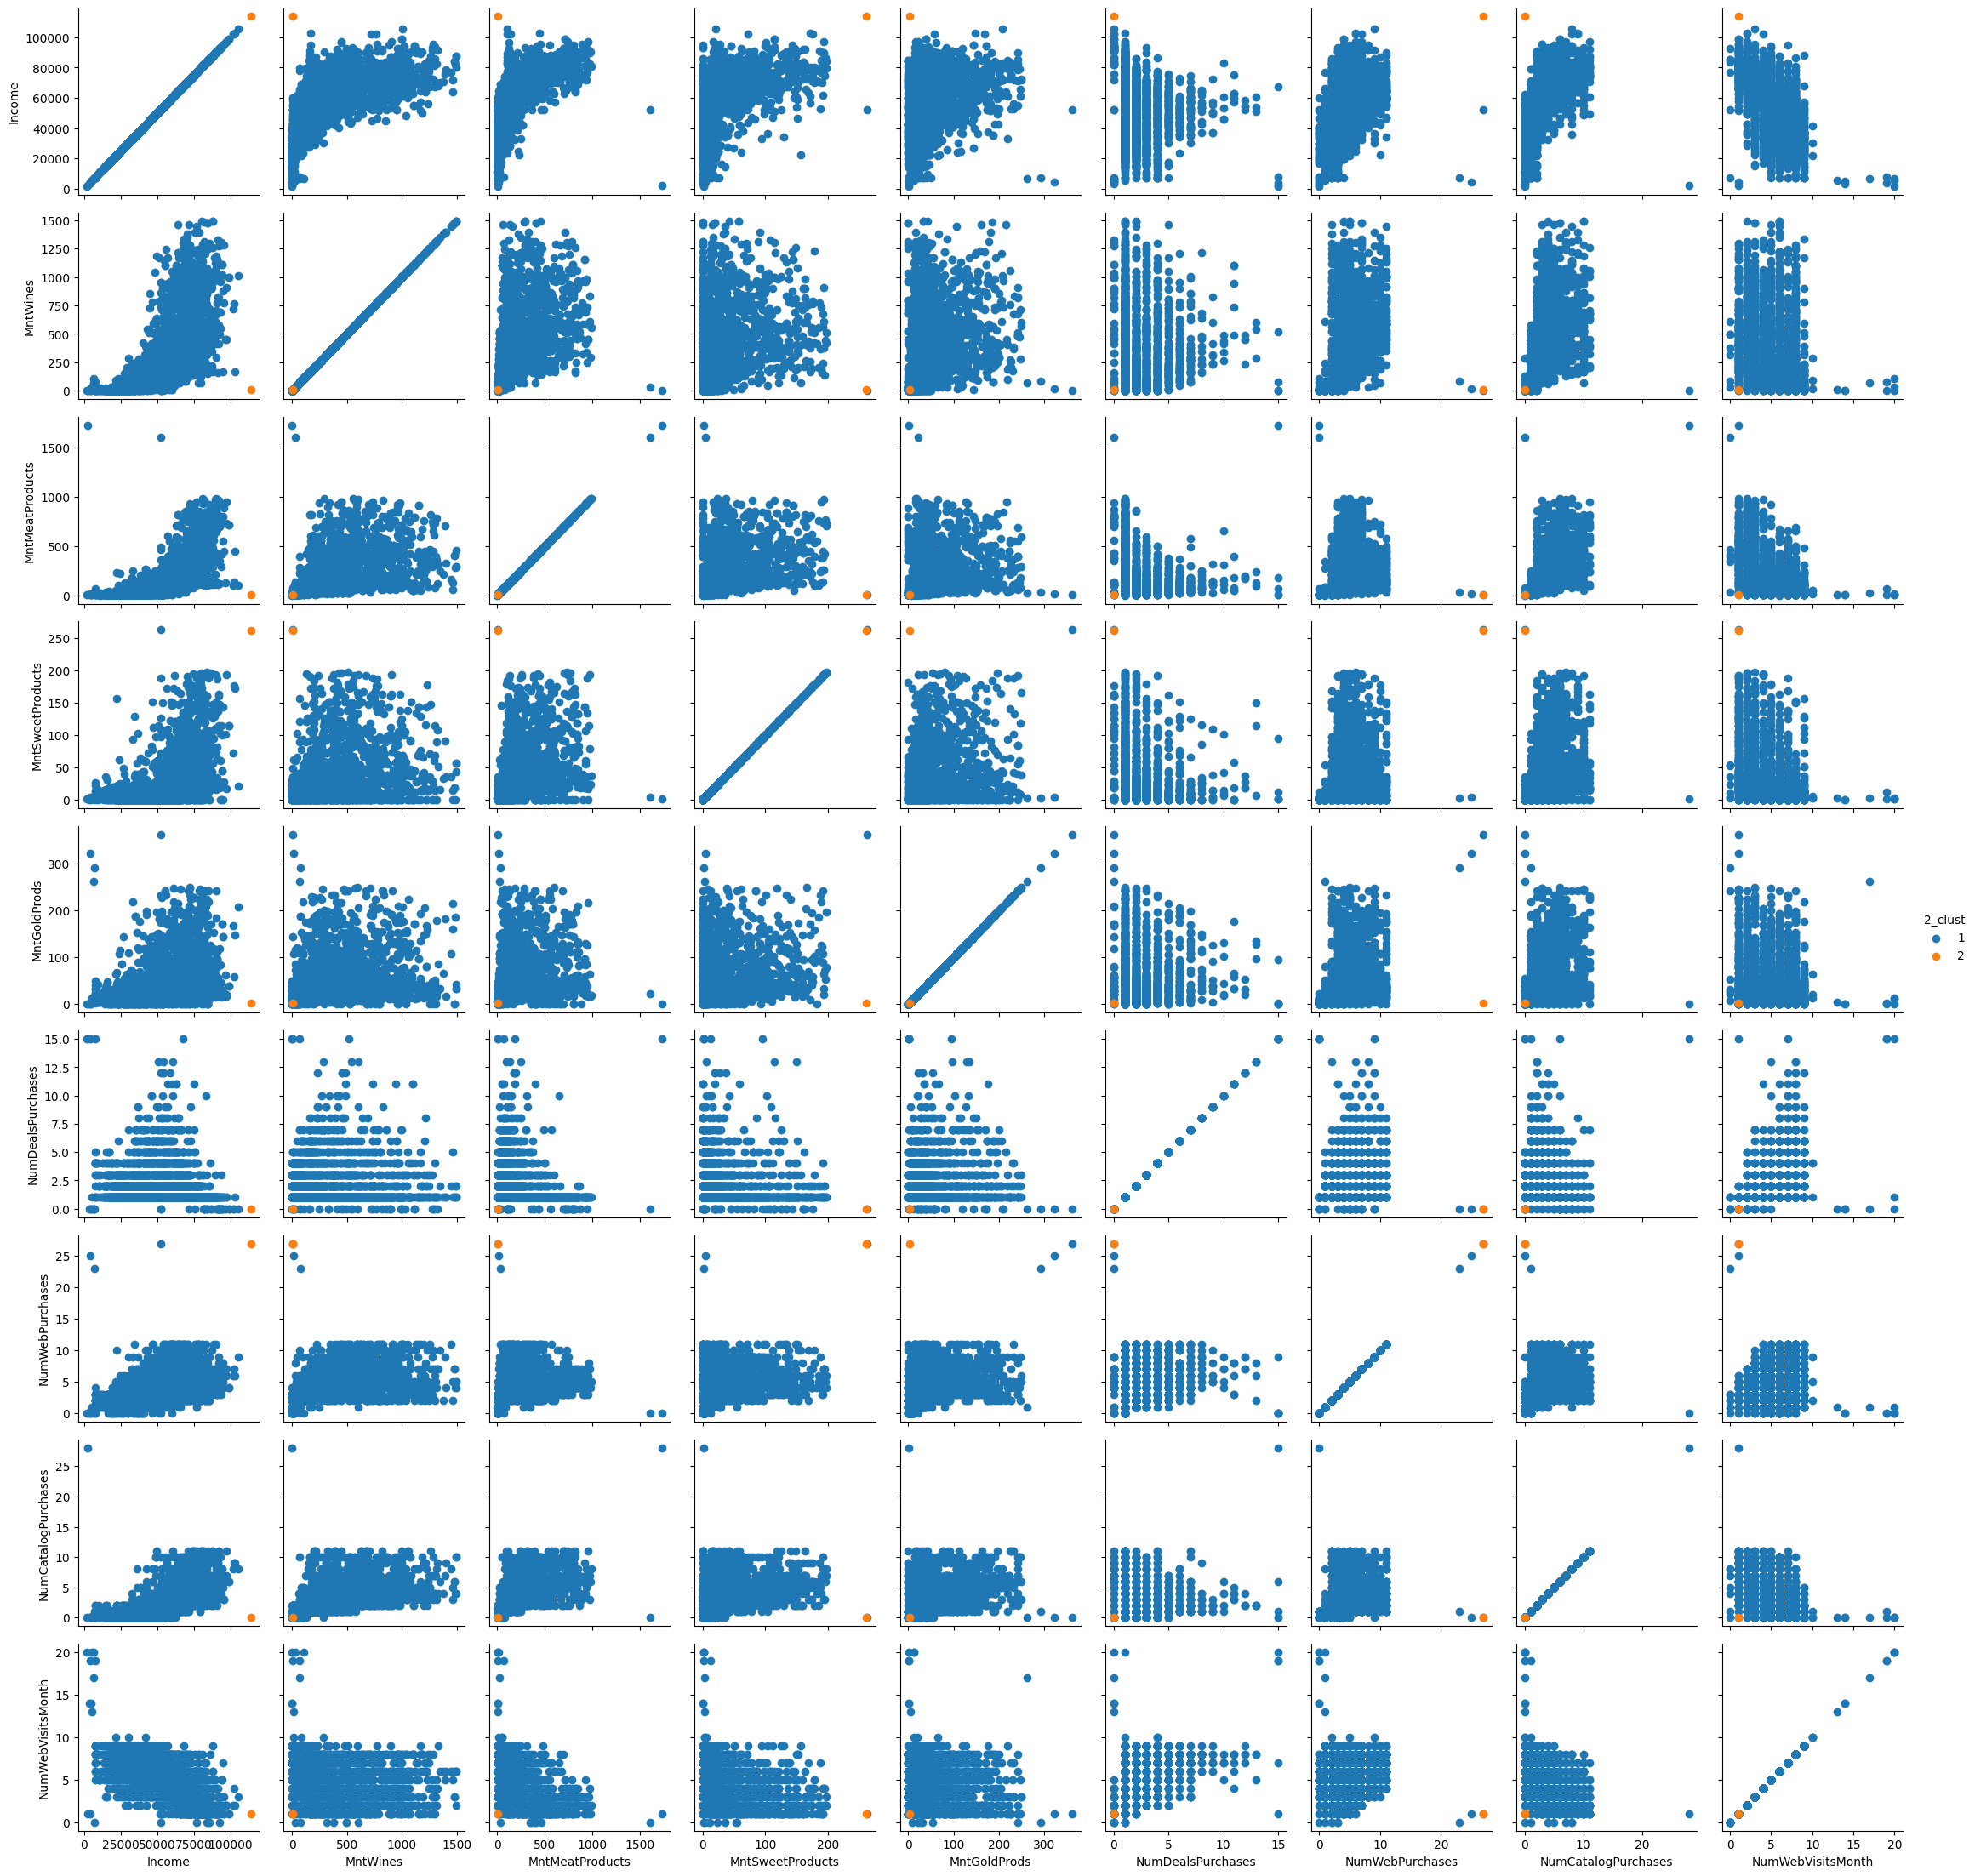

In [56]:
g = sns.PairGrid(
    X,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='2_clust')
g.map(plt.scatter)
g.add_legend();

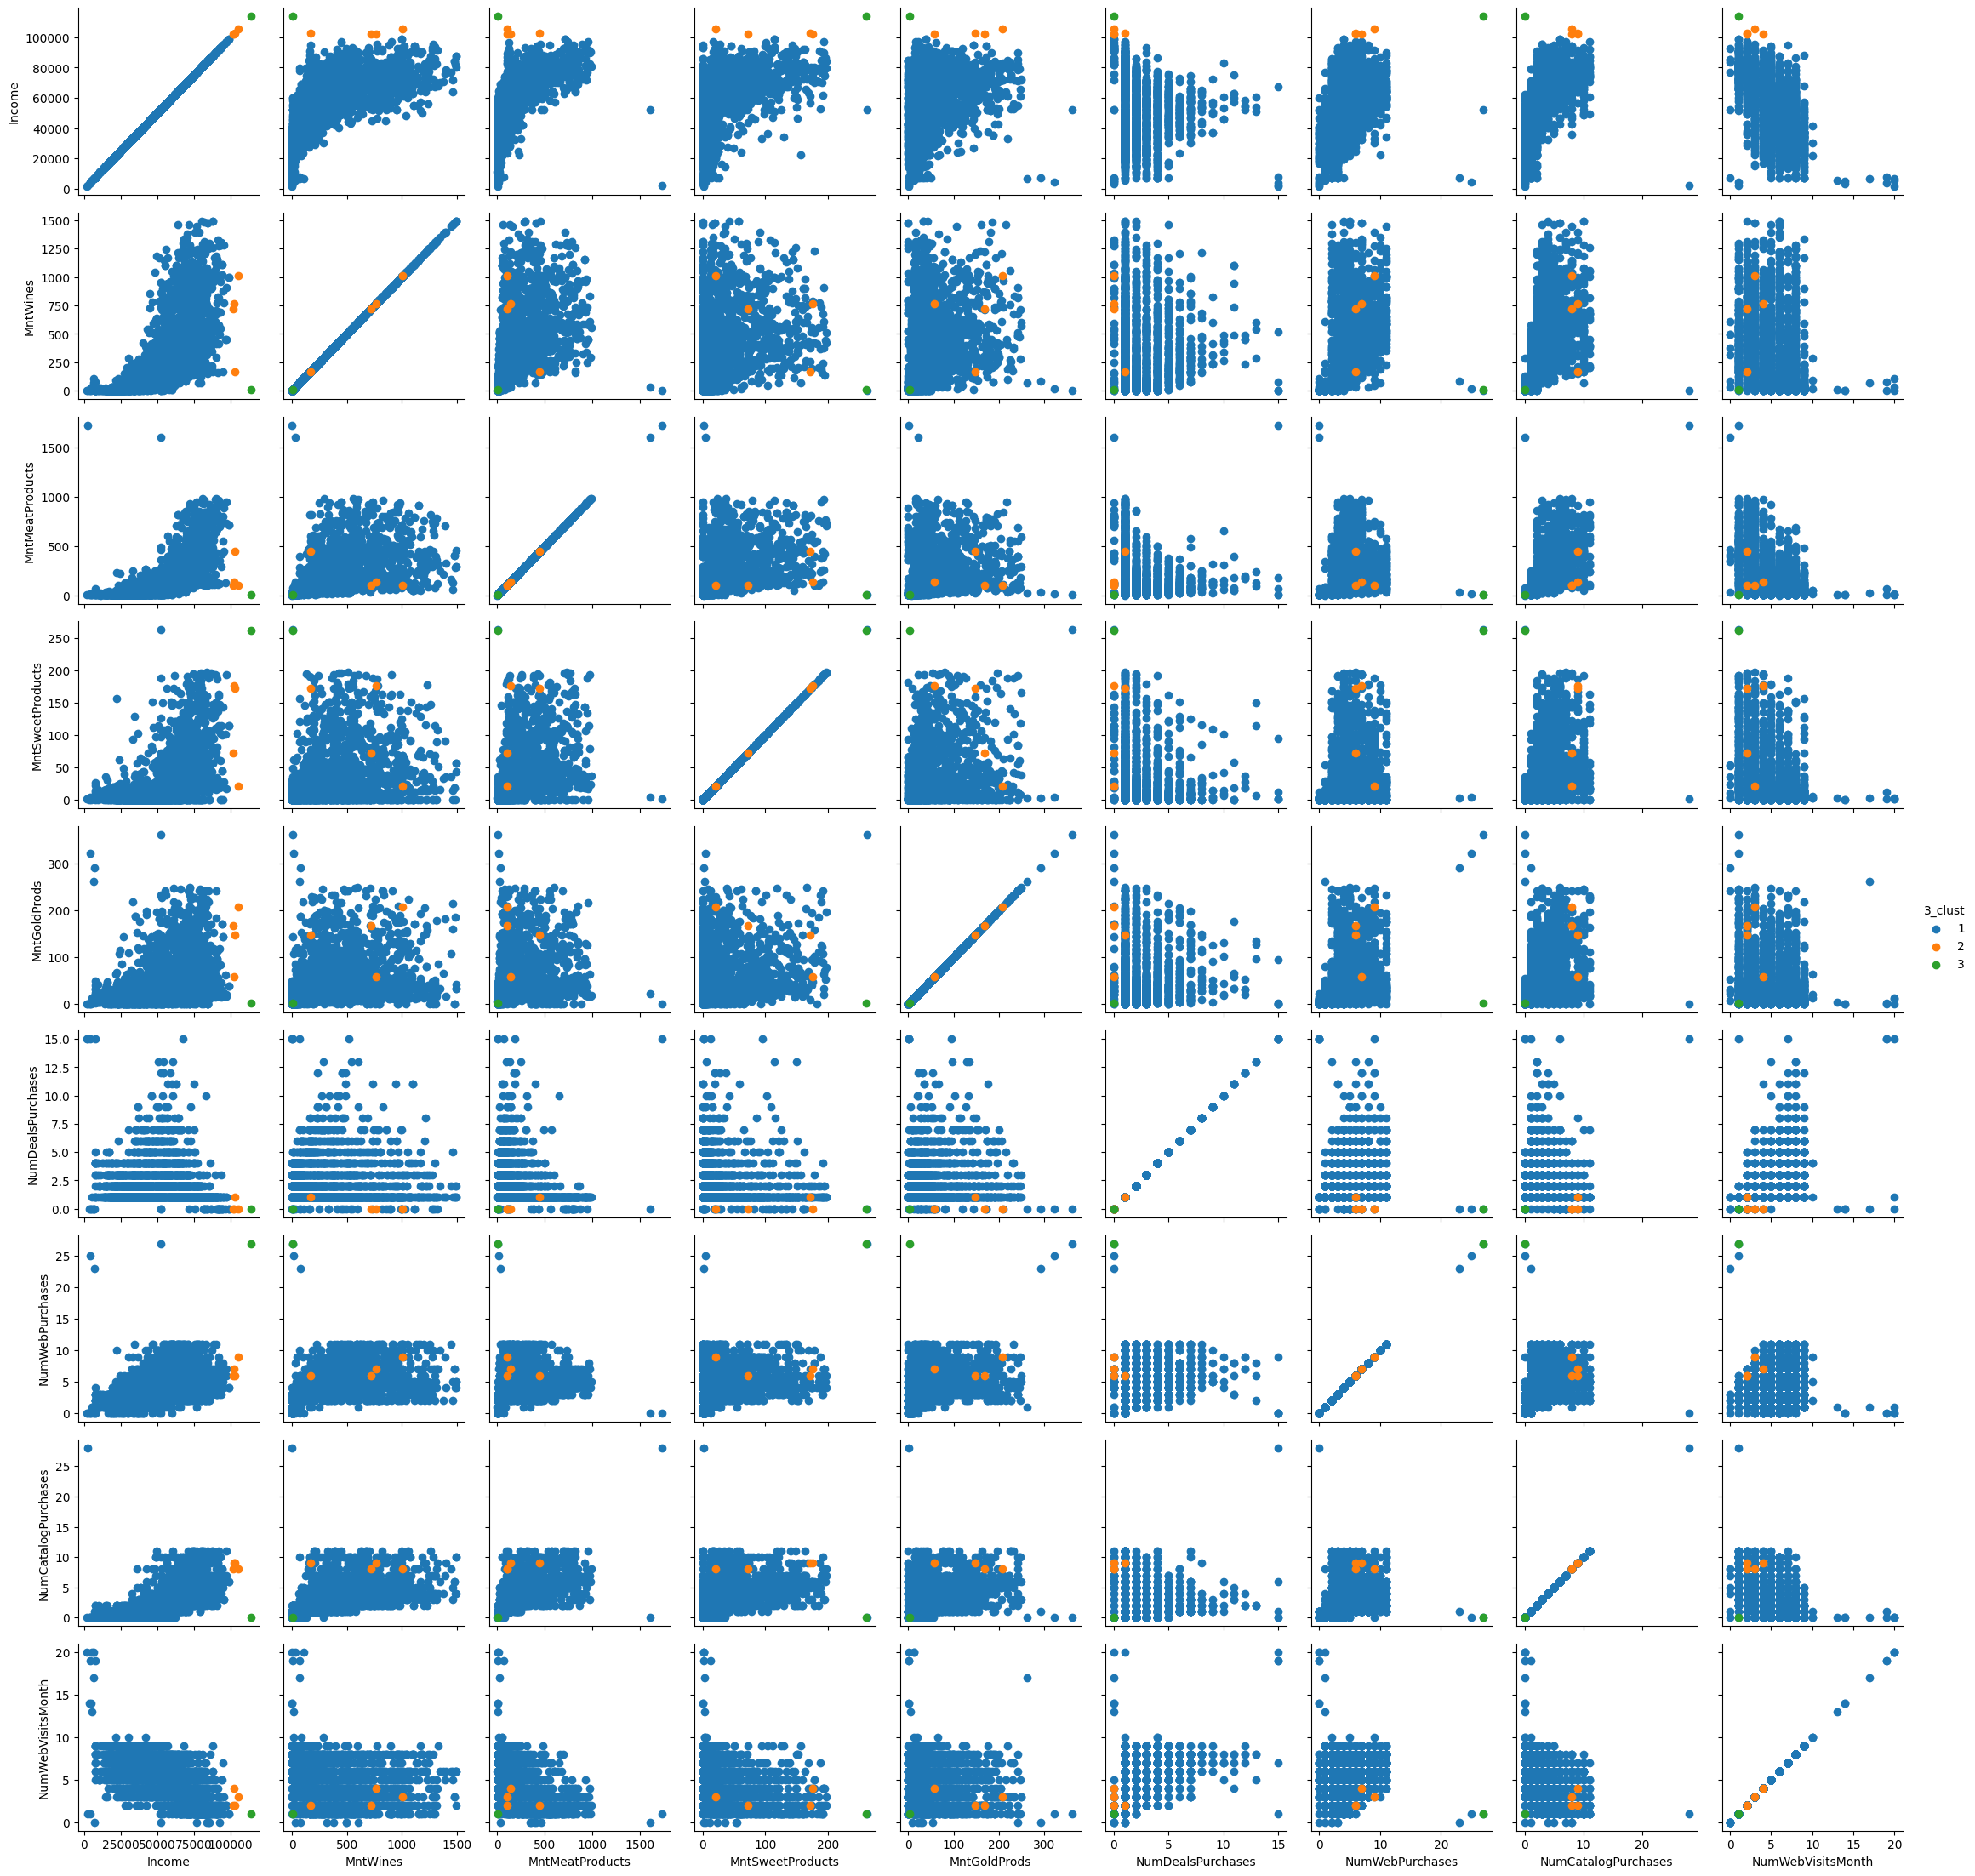

In [57]:
g = sns.PairGrid(
    X,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='3_clust')
g.map(plt.scatter)
g.add_legend();

Взагалі кластери дуже погано розбились по даному методу. 2 та 3 кластери виділяються дуже погано

In [58]:
X['2_clust'].value_counts()

,count
2_clust,
1,2231
2,1


In [59]:
X['3_clust'].value_counts()

,count
3_clust,
1,2227
2,4
3,1


По факту лиш одна точка віднеслась до окремого кластеру, де відбувається побудова двух кластерів. А для трьох кластерів - маємо 4 точки та одну для кожного кластеру окремо. Це дуже погані результати, тому це використовувати нема сенсу

In [60]:
s = metrics.silhouette_score(X[cols_for_clasterisation], fcluster(dist_sin, 2, criterion='maxclust'))
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.56


In [61]:
s = metrics.silhouette_score(X[cols_for_clasterisation], fcluster(dist_sin, 3, criterion='maxclust'))
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.45


In [62]:
s = metrics.silhouette_score(X[cols_for_clasterisation], fcluster(dist_sin, 5, criterion='maxclust'))
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.21


Хоч при побудові двух кластерів показник силуету дуже високий, але в один із кластерів входить тільки одна точка. Для використання даний метод не рекомендую

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте метрику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Повне з'єднання (Complete linkage)

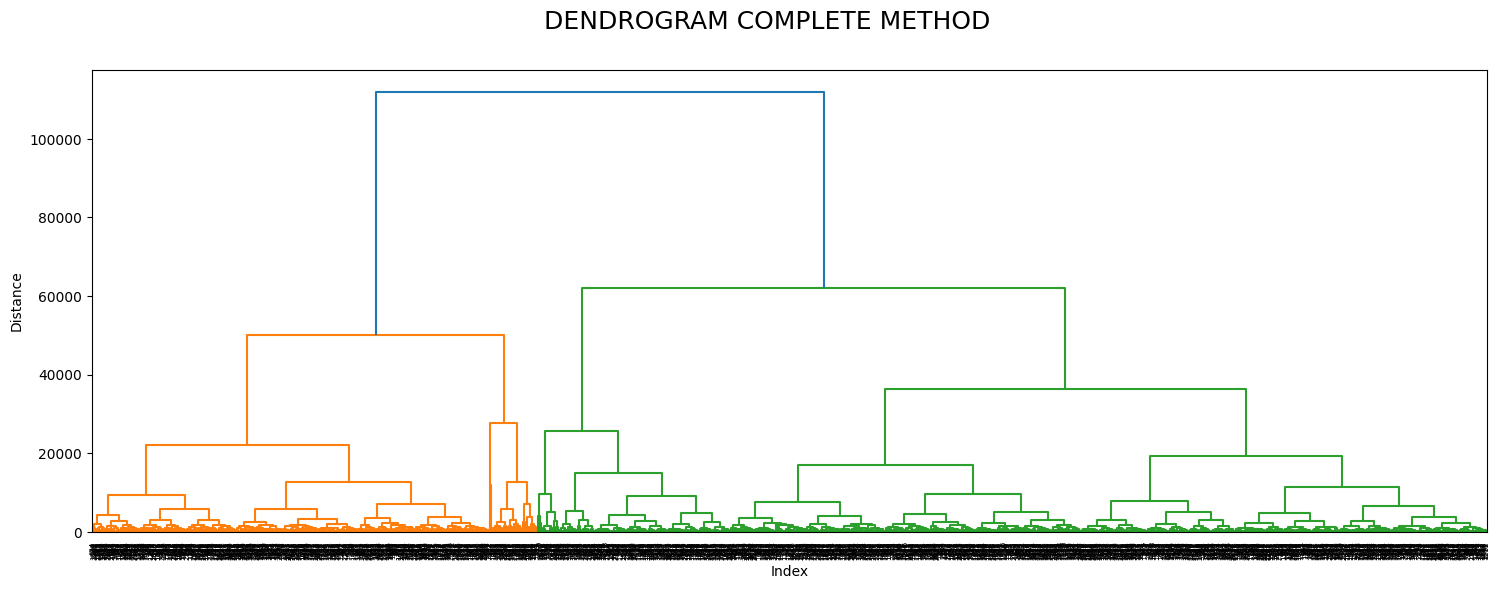

In [70]:
dist_comp = linkage(X[cols_for_clasterisation], method="complete")

plt.figure(figsize=(18,6))
dendrogram(dist_comp, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM COMPLETE METHOD",fontsize=18)
plt.show()

Взагалі тут ліпше підходить метод для двух кластерів, але зробимо для 2,3

In [71]:
X['2_clust_CM']=fcluster(dist_comp, 2, criterion='maxclust')
X['3_clust_CM']=fcluster(dist_comp, 3, criterion='maxclust')

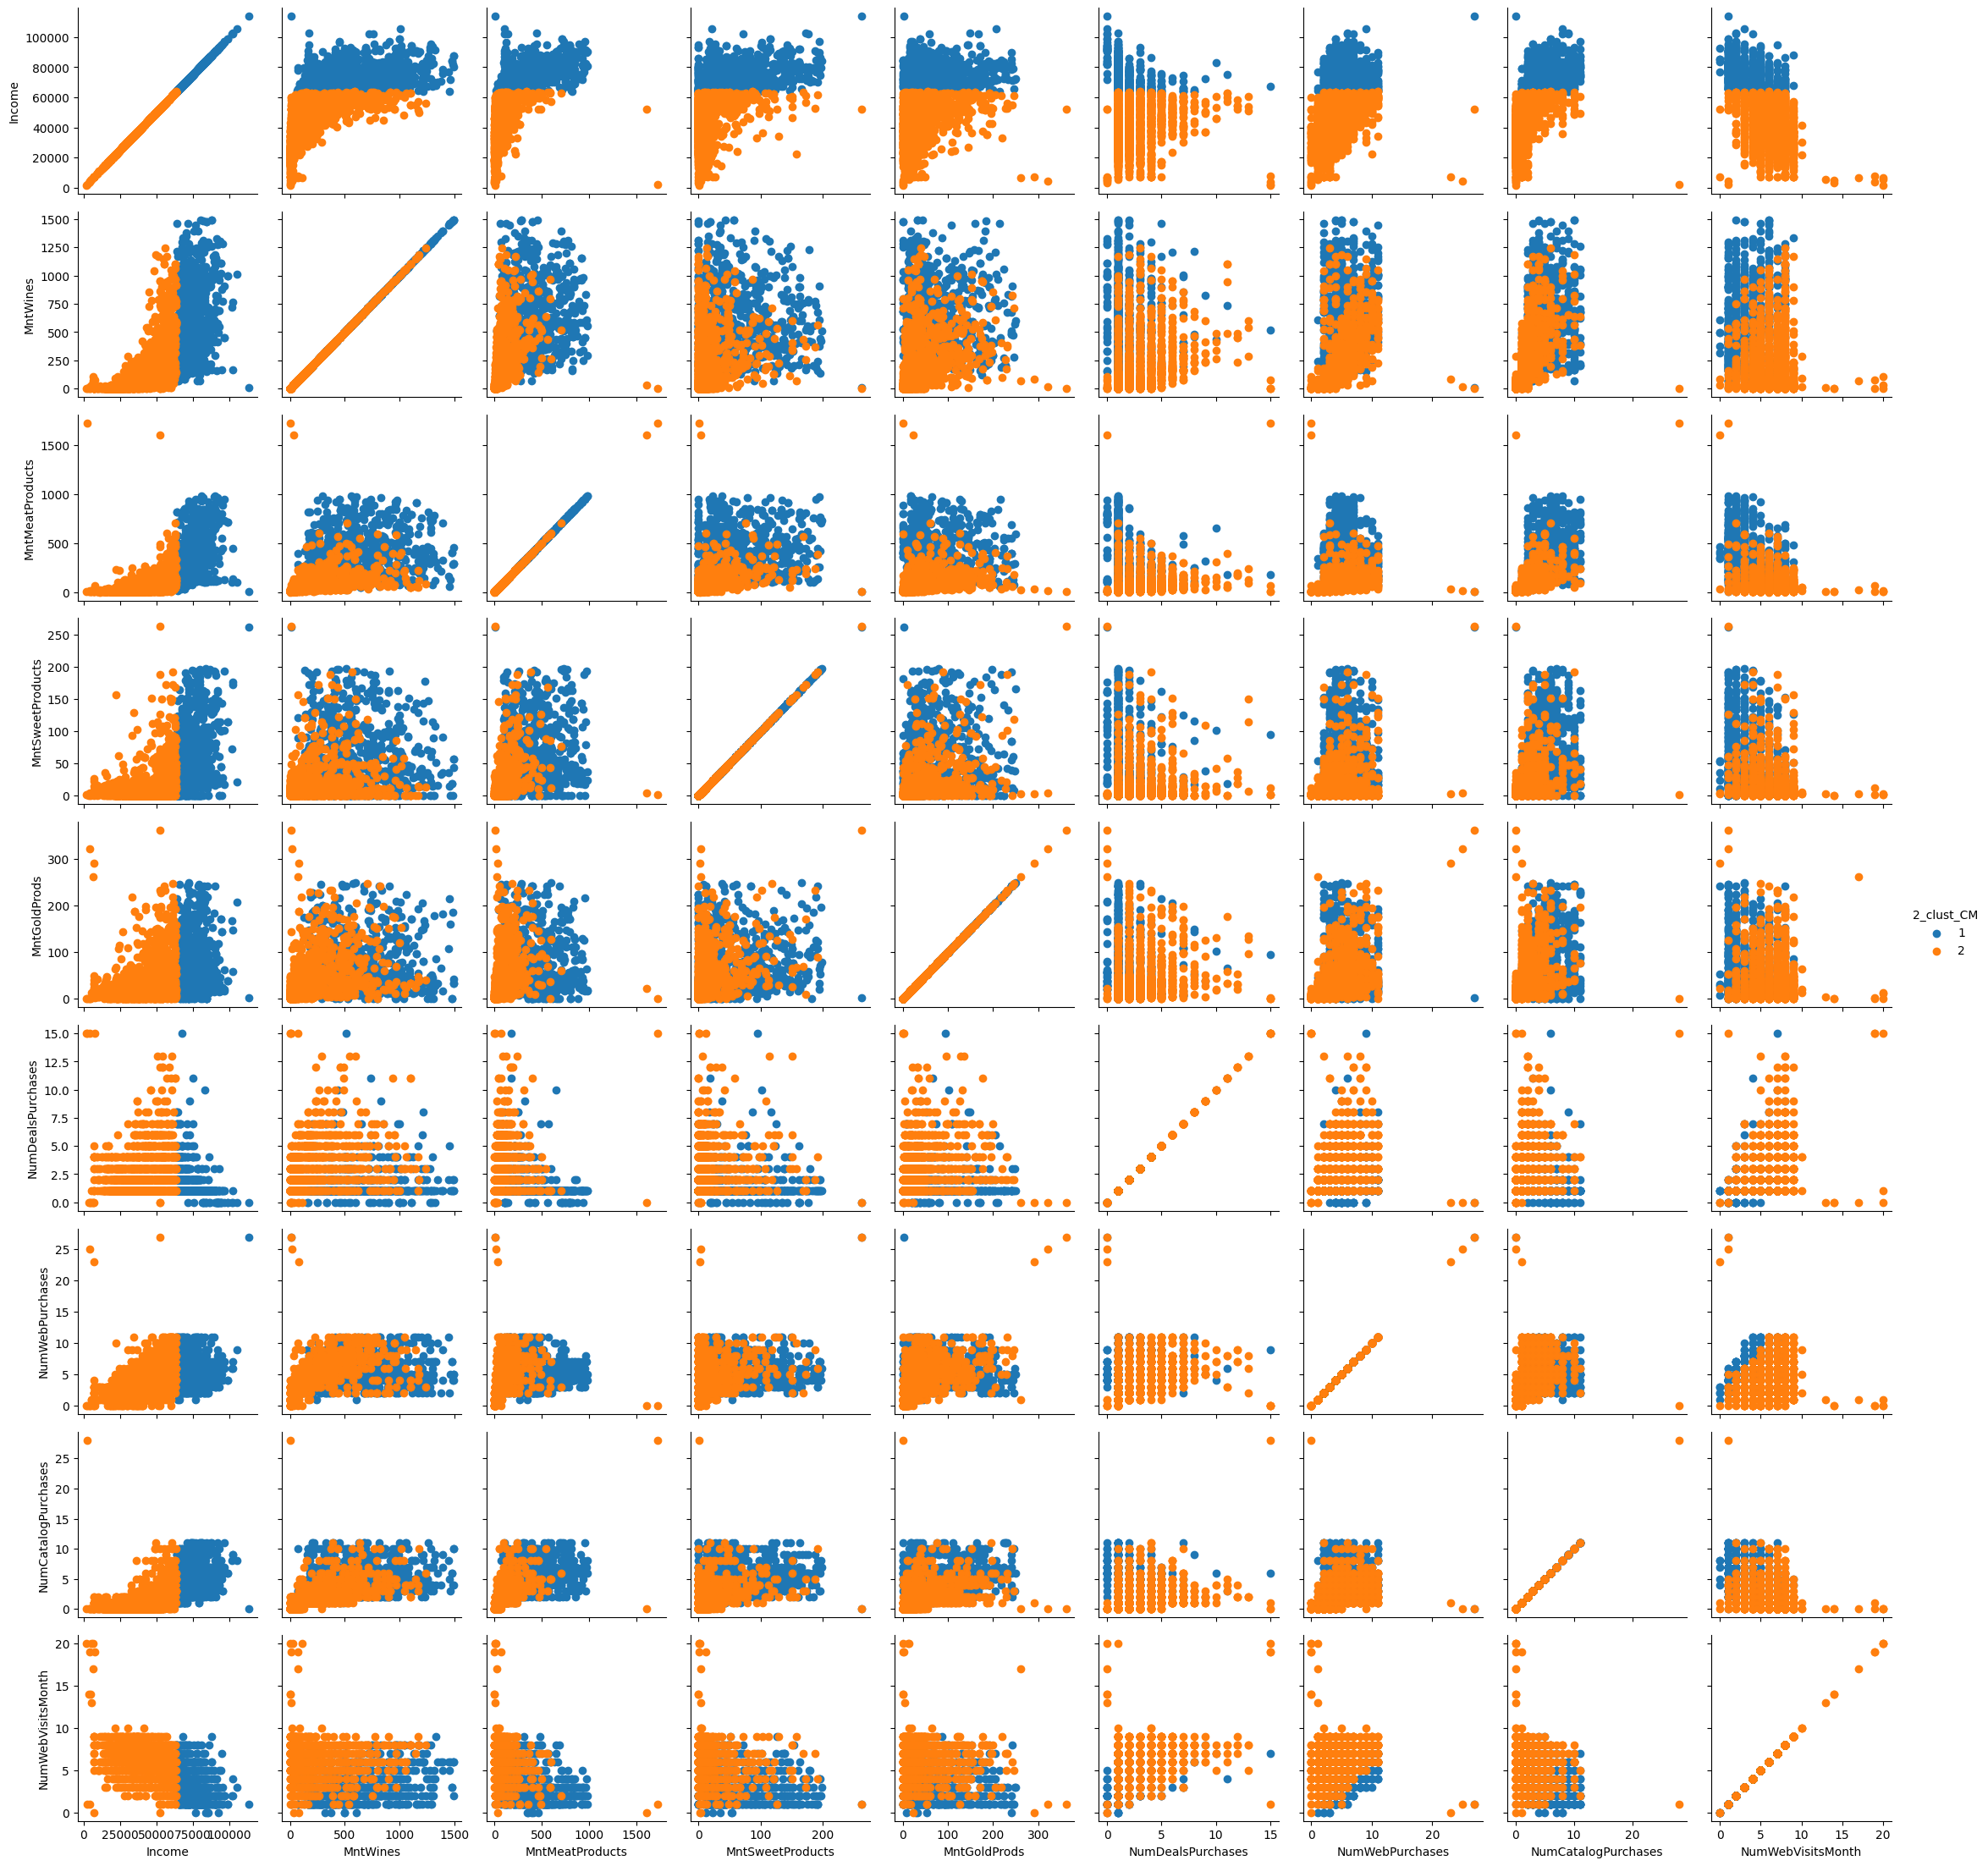

In [72]:
g = sns.PairGrid(
    X,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='2_clust_CM')
g.map(plt.scatter)
g.add_legend();

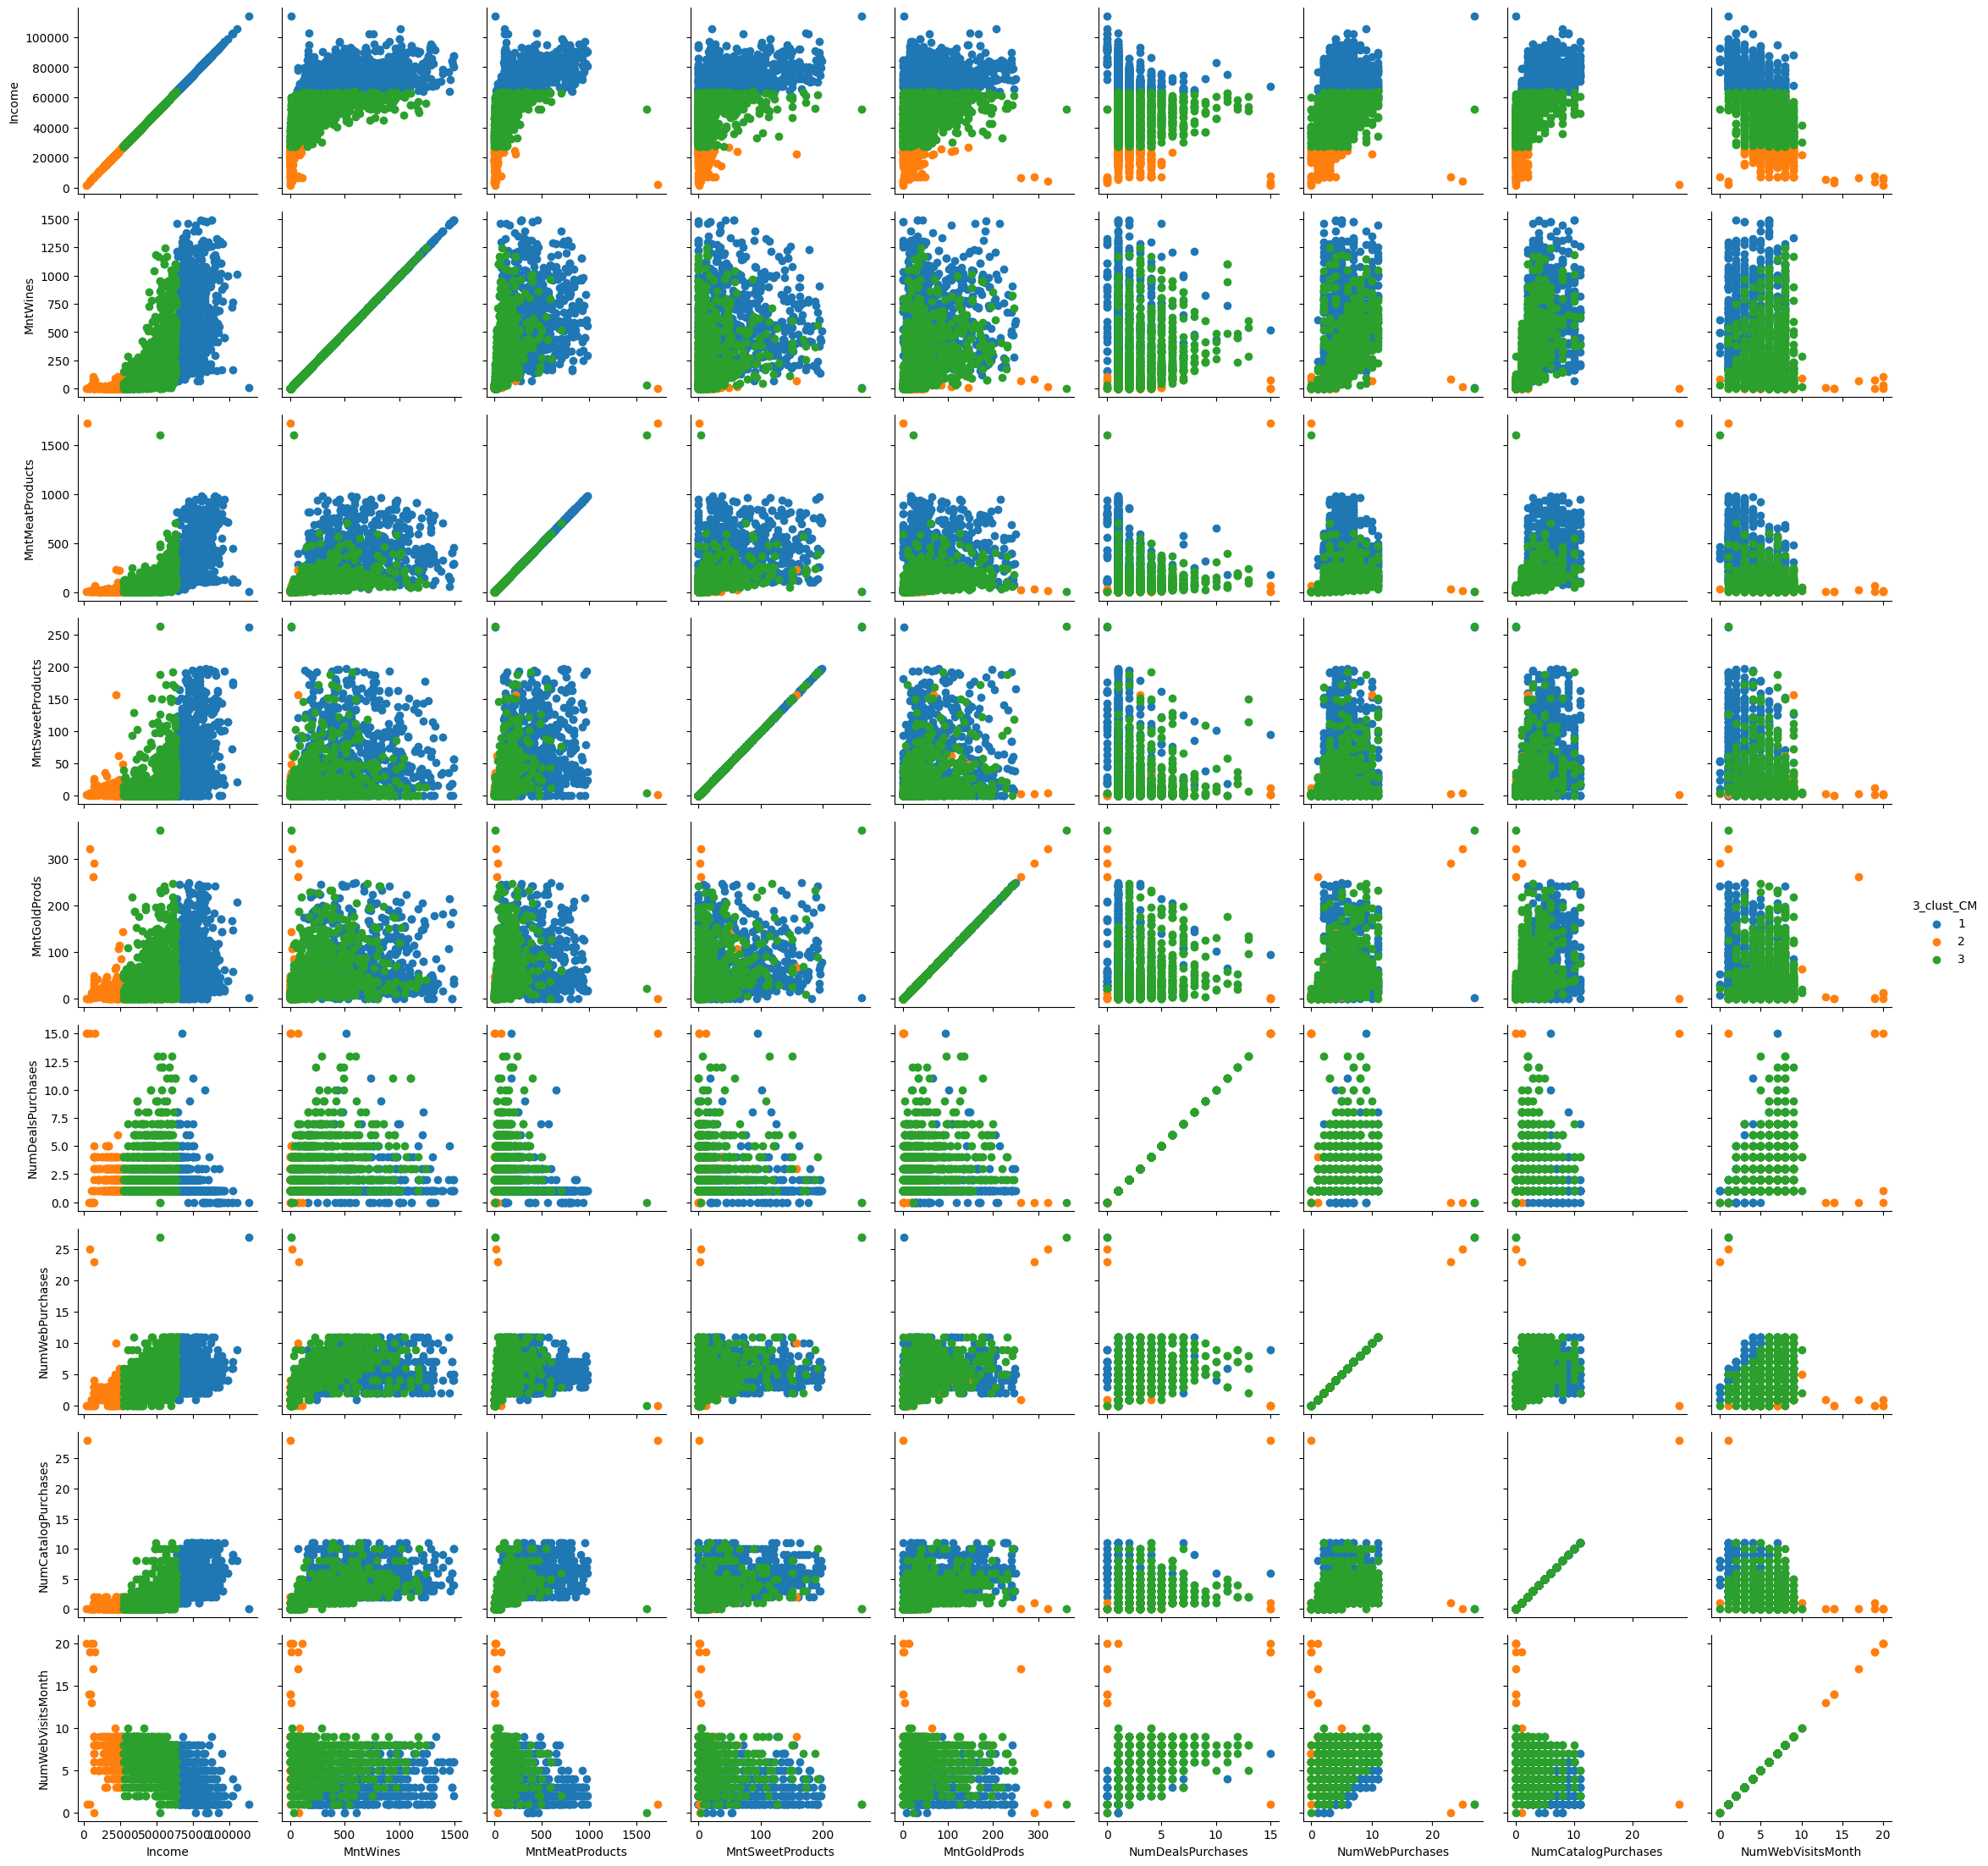

In [73]:
g = sns.PairGrid(
    X,
    vars=['Income','MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumWebVisitsMonth'],
    hue='3_clust_CM')
g.map(plt.scatter)
g.add_legend();

In [76]:
s = metrics.silhouette_score(X[cols_for_clasterisation], fcluster(dist_comp, 2, criterion='maxclust'))
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.54


In [77]:
s = metrics.silhouette_score(X[cols_for_clasterisation], fcluster(dist_comp, 3, criterion='maxclust'))
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.48


По результатам кластеризації методу повного з'єднання помітні подібні результати показників силуету та візуальне розбиття, як і в KMEANS. Тому даний метод можна використовувати в кластеризації на двух або трьох кластерах (в залежності від необхідної к-сті кластерів для компанії)

#Аналіз метрик силуету та вибір оптимальної кількості кластерів в KMEANS

In [86]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

Для n_clusters = 2 Середнє значення silhouette_score становить: 0.601873335324781
Для n_clusters = 3 Середнє значення silhouette_score становить: 0.5516442578217884
Для n_clusters = 4 Середнє значення silhouette_score становить: 0.5334173945342081
Для n_clusters = 5 Середнє значення silhouette_score становить: 0.5397927655092254
Для n_clusters = 6 Середнє значення silhouette_score становить: 0.5144753661143548


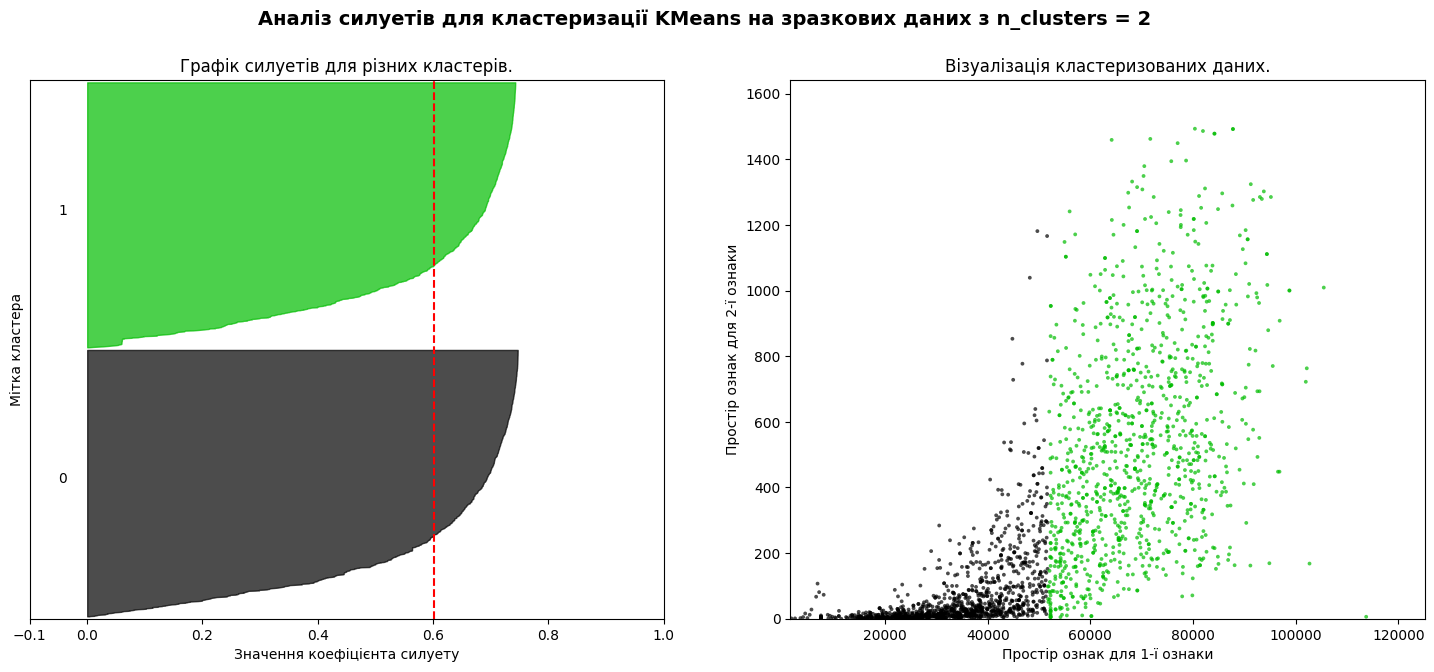

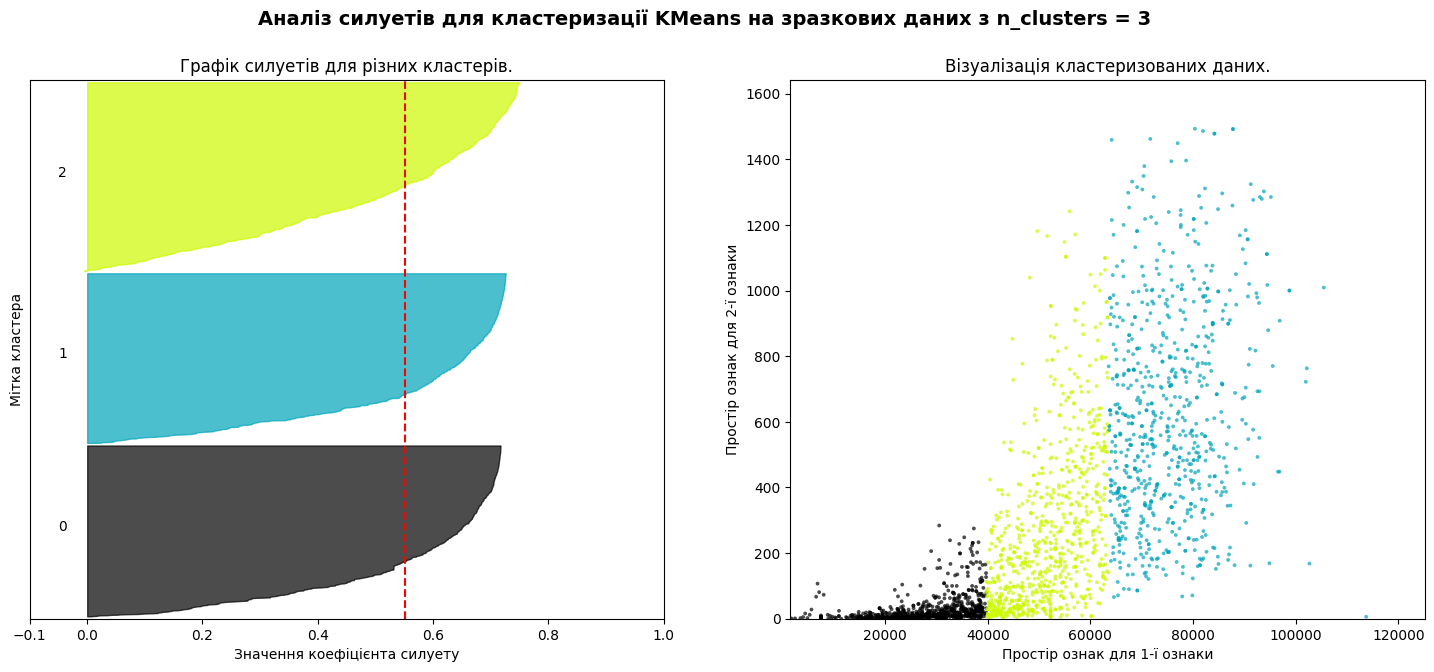

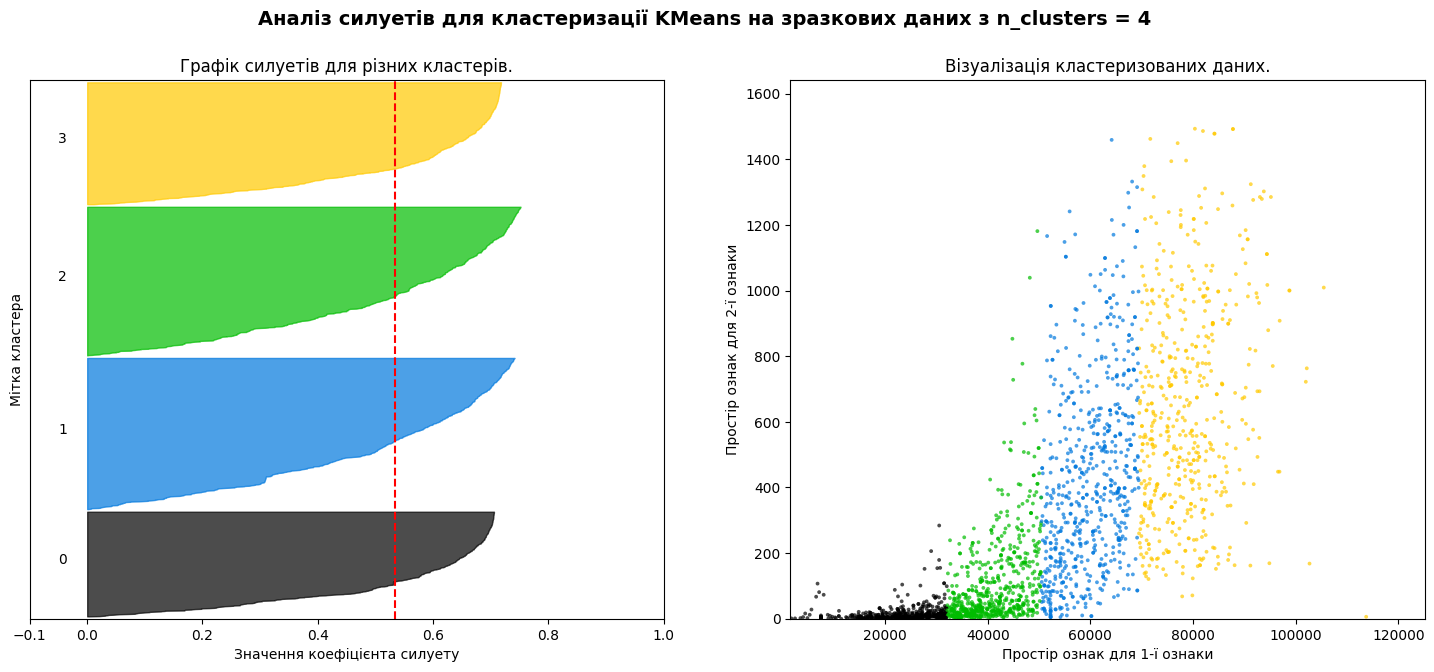

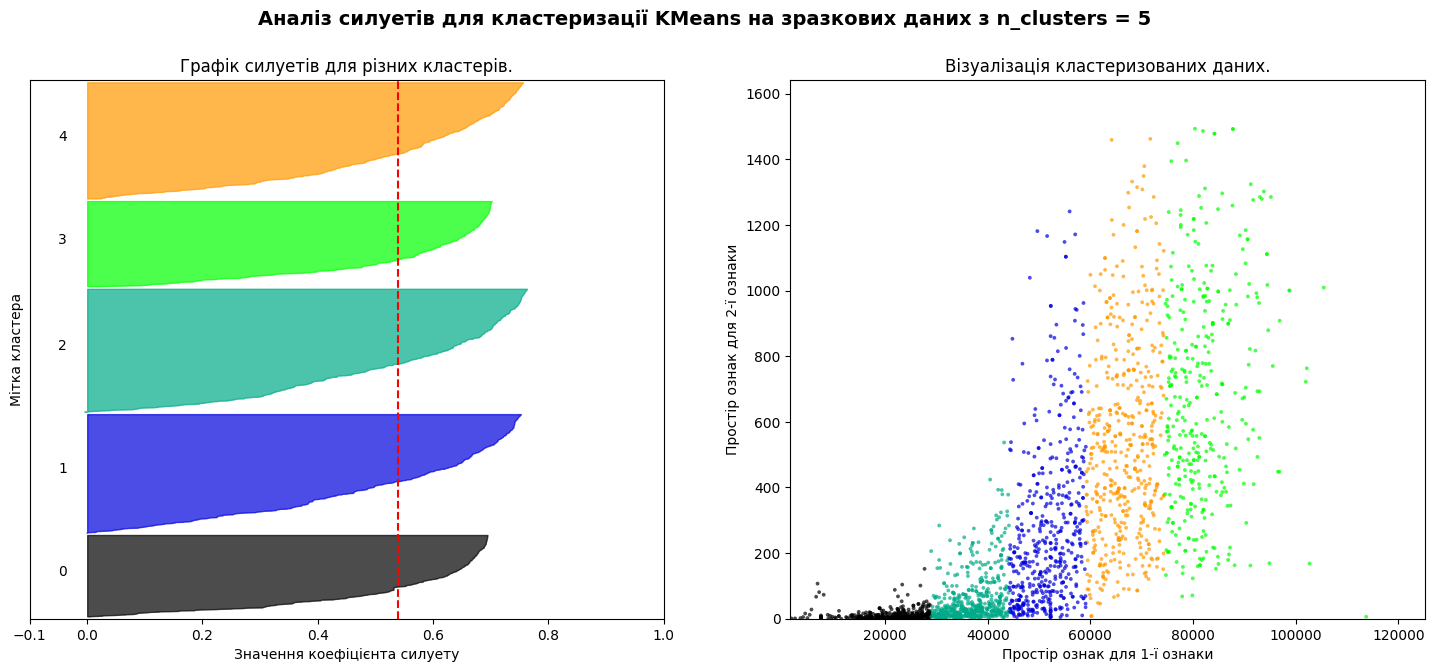

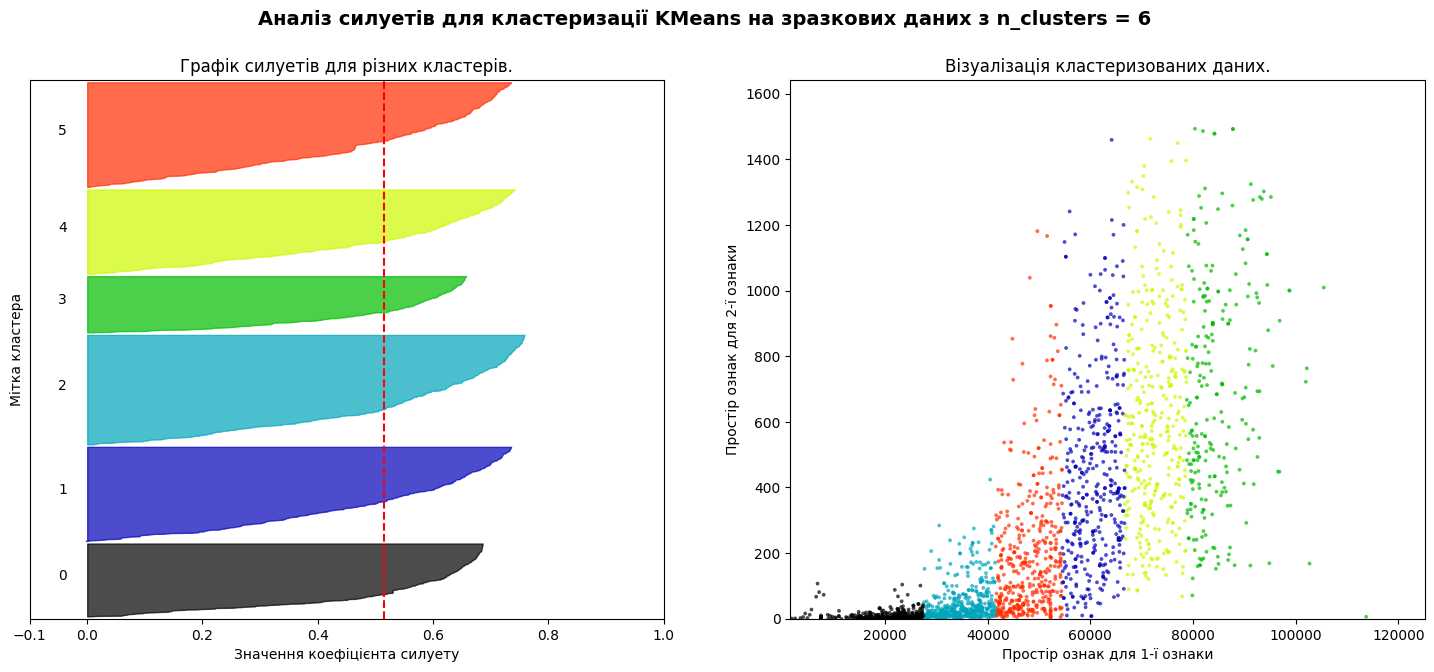

In [85]:
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # 1-й підграфік - це графік силуетів. Коефіцієнт силуету може варіюватися від -1 до 1, але в цьому прикладі всі значення лежать в межах [-0.1, 1].
    ax1.set_xlim([-0.1, 1])
    # (N_clusters + 1) * 10 призначено для вставки пустого простору між графіками силуетів окремих кластерів, щоб чітко їх розмежувати.
    ax1.set_ylim([0, len(X[cols_for_clasterisation]) + (n_clusters + 1) * 10])

    # Ініціюємо кластеризатор
    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X[cols_for_clasterisation])
    silhouette_avg = silhouette_score(X[cols_for_clasterisation], cluster_labels)
    print(
        "Для n_clusters =",
        n_clusters,
        "Середнє значення silhouette_score становить:",
        silhouette_avg,
    )

    # Розраховуємо метрику силуету для кожного екземпляра в наборі даних
    sample_silhouette_values = silhouette_samples(X[cols_for_clasterisation], cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Агрегація оцінок силуетів для зразків, що належать кластеру i, і їх сортування
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Позначимо силуетні області номерами кластерів посередині.
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Обчислимо нове значення y_lower для наступного графіка
        y_lower = y_upper + 10

    ax1.set_title("Графік силуетів для різних кластерів.")
    ax1.set_xlabel("Значення коефіцієнта силуету")
    ax1.set_ylabel("Мітка кластера")

    # Вертикальна лінія - середнє значення силуету для всіх значень.
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Прибрати мітки на осі y
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2-й підграфік, що показує фактично сформовані кластери
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.set_aspect('auto')  # або 'equal' для 1:1
    ax2.set_xlim(X['Income'].min() * 0.9, X['Income'].max() * 1.1)
    ax2.set_ylim(X['MntWines'].min() * 0.9, X['MntWines'].max() * 1.1)
    ax2.scatter(
        X['Income'], X['MntWines'], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Центри кластерів
    centers = clusterer.cluster_centers_
    # Білі кружечки в центрі кластерів
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("Візуалізація кластеризованих даних.")
    ax2.set_xlabel("Простір ознак для 1-ї ознаки")
    ax2.set_ylabel("Простір ознак для 2-ї ознаки")

    plt.suptitle(
        "Аналіз силуетів для кластеризації KMeans на зразкових даних з n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Додатково ще зробила аналітику силуету по кластеризації KMeans, де можна оцінити необхідну к-сть кластерів.  В результаті, по показникам силуету - найкращим варіантом є розбиття на два кластери